**Menghubungkan Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install library
!pip install transformers datasets torch tensorflow gensim pyLDAvis Sastrawi nltk emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 46.8 MB/s eta 0:00:00


# **Import Library**

In [ ]:
# Import library
import pandas as pd
import numpy as np
import re
import emoji
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm
import string
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
import gensim
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

# **Load Dataset**

In [ ]:
# Load the dataset
mbg = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/datafix.csv', sep=';', encoding='latin-1')
mbg

,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,text,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions
0,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7546441081128715026,1757042745,2025-09-05T03:25:45.000Z,Tapi emang serius buat kalian yang gak setuju ...,1123,False,False,NaN,78,6919065970405803009,itsmeeziie,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
1,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545282660869866257,1756773041,2025-09-02T00:30:41.000Z,terus yang menghujat makanan bergizi adalah or...,1333,False,False,NaN,35,7306677669742265349,dewipurwaningsih371,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
2,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545338915633693458,1756786126,2025-09-02T04:08:46.000Z,mkn yg enak ya dek itu hasil kami melawan anak...,6230,True,False,NaN,279,7139233608912651291,elvimustikasari,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
3,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545329959843119873,1756784049,2025-09-02T03:34:09.000Z,Tolong yaaaa. Yg di bagian dapur yang buat mas...,370,False,False,NaN,16,7078516901723653121,qurrotiayuninekasafitri,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
4,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7527194850573714194,1752561634,2025-07-15T06:40:34.000Z,dilingkungan teman ahli giziku banyak yg hujat...,2148,True,False,NaN,134,7374188813495321605,piupiu3775,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9749,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432365896958728,1759136187,2025-09-29T08:56:27.000Z,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...",0,False,False,NaN,0,7447552282370360338,andikaa_yoga,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9750,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432233621209863,1759136157,2025-09-29T08:55:57.000Z,cuan cuan,0,False,False,NaN,0,6831128621555532802,wibu_cool1,https://p16-common-sign.tiktokcdn-us.com/tos-m...,[],[]
9751,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432215867327233,1759136159,2025-09-29T08:55:59.000Z,??,0,False,False,NaN,0,7477231474900976657,fransensius,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9752,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432209302881042,1759136297,2025-09-29T08:58:17.000Z,aq suka program bmg.yg keracunan tengok aj yg ...,0,False,False,NaN,0,7523212335663907856,nurasidikia,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]


In [ ]:
# Check NA or missing values
mbg = mbg.dropna(subset=['text']).reset_index(drop=True)
mbg

,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,text,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions
0,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7546441081128715026,1757042745,2025-09-05T03:25:45.000Z,Tapi emang serius buat kalian yang gak setuju ...,1123,False,False,NaN,78,6919065970405803009,itsmeeziie,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
1,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545282660869866257,1756773041,2025-09-02T00:30:41.000Z,terus yang menghujat makanan bergizi adalah or...,1333,False,False,NaN,35,7306677669742265349,dewipurwaningsih371,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
2,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545338915633693458,1756786126,2025-09-02T04:08:46.000Z,mkn yg enak ya dek itu hasil kami melawan anak...,6230,True,False,NaN,279,7139233608912651291,elvimustikasari,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
3,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7545329959843119873,1756784049,2025-09-02T03:34:09.000Z,Tolong yaaaa. Yg di bagian dapur yang buat mas...,370,False,False,NaN,16,7078516901723653121,qurrotiayuninekasafitri,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
4,https://www.tiktok.com/@sppgbgn/video/75268199...,https://vt.tiktok.com/ZSy6fm2aN/,https://vt.tiktok.com/ZSy6fm2aN/,7527194850573714194,1752561634,2025-07-15T06:40:34.000Z,dilingkungan teman ahli giziku banyak yg hujat...,2148,True,False,NaN,134,7374188813495321605,piupiu3775,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9735,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432365896958728,1759136187,2025-09-29T08:56:27.000Z,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...",0,False,False,NaN,0,7447552282370360338,andikaa_yoga,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9736,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432233621209863,1759136157,2025-09-29T08:55:57.000Z,cuan cuan,0,False,False,NaN,0,6831128621555532802,wibu_cool1,https://p16-common-sign.tiktokcdn-us.com/tos-m...,[],[]
9737,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432215867327233,1759136159,2025-09-29T08:55:59.000Z,??,0,False,False,NaN,0,7477231474900976657,fransensius,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9738,https://www.tiktok.com/@inilahcom/video/755542...,https://vt.tiktok.com/ZSy6fhFnb/,https://vt.tiktok.com/ZSy6fhFnb/,7555432209302881042,1759136297,2025-09-29T08:58:17.000Z,aq suka program bmg.yg keracunan tengok aj yg ...,0,False,False,NaN,0,7523212335663907856,nurasidikia,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]


In [ ]:
# Hapus kolom kecuali text
mbg.drop(columns=[
    'videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime',
       'createTimeISO','diggCount', 'likedByAuthor', 'pinnedByAuthor',
       'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId',
       'avatarThumbnail', 'mentions', 'detailedMentions', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22'
], inplace=True, errors='ignore')

mbg.head()

,text
0,Tapi emang serius buat kalian yang gak setuju ...
1,terus yang menghujat makanan bergizi adalah or...
2,mkn yg enak ya dek itu hasil kami melawan anak...
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...
4,dilingkungan teman ahli giziku banyak yg hujat...


In [ ]:
mbg = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/mbgtanpaNAbaru.csv', sep=';', encoding='latin-1')
mbg

,text
0,Tapi emang serius buat kalian yang gak setuju ...
1,terus yang menghujat makanan bergizi adalah or...
2,mkn yg enak ya dek itu hasil kami melawan anak...
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...
4,dilingkungan teman ahli giziku banyak yg hujat...
...,...
9734,"niatmu baik pak, Tapi 15rb tinggal ..... ladan..."
9735,cuan cuan
9736,??
9737,aq suka program bmg.yg keracunan tengok aj yg ...


# **Pre-Processing**

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load Stopword dan Stemmer

stop_words = set(stopwords.words('indonesian'))
tambahan = {'deh', 'dong', 'sih', 'lah', 'nih', 'tuh', 'nya', 'mua', 'nyh'}
stop_words = stop_words.union(tambahan)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Load Kamus Normalisasi

df_norm = pd.read_csv(
    '/content/drive/MyDrive/Tugas Akhir/Data/normalbaru.txt',
    sep=',',
    header=None,
    names=["salah","benar"],
    engine='python',
    on_bad_lines='skip'
)

In [ ]:
df_norm = df_norm.dropna()

In [ ]:
df_norm.head(5)

,salah,benar
0,salah,benar
1,Tapi,tetapi
2,tapi,tetapi
3,mkn,makan
4,yg,yang


In [ ]:
df_norm.tail(5)

,salah,benar
16490,4,empat
16491,di berikan,diberikan
16492,di minati,diminati
16493,di pangkas,dipangkas
16494,adik2ku,adik-adik saya


In [ ]:
kamus_norm = dict(zip(df_norm['salah'], df_norm['benar']))

In [ ]:
with open('/content/drive/MyDrive/Tugas Akhir/Data/normalbaru.txt', 'r') as f:
    for i, line in enumerate(f):
        if line.count(',') != 1:
            print(f"Baris {i}: {line}")

In [ ]:
# cek apakah ada NaN di kamus
print(any(pd.isnull(v) for v in kamus_norm.values()))

False


In [ ]:
# Case Folding

def case_folding(text):
    if pd.isnull(text):
        return ""
    return text.lower()

mbg['case_folding'] = mbg['text'].apply(case_folding)


In [ ]:
# Data Cleansing

def cleansing(text):

    text = emoji.replace_emoji(text, "")

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"@\w+|#\w+", "", text)

    text = re.sub(r'(\d+)[\.,](\d+)', r'\1DECIMAL\2', text) # Melindungi desimal

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # Hapus Tanda baca

    text = re.sub(r"\s+", " ", text).strip()

    text = re.sub(r'(.)\1{2,}', r'\1', text)

    text = re.sub(r'(\d+)DECIMAL(\d+)', r'\1.\2', text) # balikin ke desimal

    # Hapus punctuation berlebih
    text = re.sub(r'[^\w\s]', ' ', text)

    # Hapus multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # hapus variasi wkwk (lebih fleksibel)
    text = re.sub(r'\bwk+\b', '', text)

    # hapus variasi haha
    text = re.sub(r'\bha(ha)+\b', '', text)

    # hapus variasi hmm
    text = re.sub(r'\bhm+\b', '', text)

    # hapus variasi p pp
    text = re.sub(r'\bp+\b', '', text)
    return text

mbg['clean_text'] = mbg['case_folding'].apply(cleansing)

# hapus data kosong
mbg = mbg[mbg['clean_text'].str.strip() != ""]

In [ ]:
# Cek NA di Clean_Text
mbg['clean_text'].isnull().sum()

np.int64(0)

In [ ]:
mbg

,text,case_folding,clean_text
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...
...,...,...,...
9733,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan
9734,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...","niatmu baik pak, tapi 15rb tinggal ..... ladan...",niatmu baik pak tapi 15rb tinggal ladang korup...
9735,cuan cuan,cuan cuan,cuan cuan
9737,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg yg keracunan tengok aj yg ...


In [ ]:
mbg = mbg[mbg['clean_text'].str.strip() != ""].copy()

In [ ]:
# Normalisasi
def normalisasi(text):

    text = str(text)

    words = text.split()

    normalized = []
    for word in words:
        hasil = kamus_norm.get(word, word)

        if pd.isnull(hasil) or hasil == '':
            hasil = word

        normalized.append(str(hasil))

    return " ".join(normalized)

mbg = mbg.copy()
mbg['normalized_text'] = mbg['clean_text'].apply(normalisasi)

In [ ]:
mbg

,text,case_folding,clean_text,normalized_text
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tetapi memang serius untuk kalian yang tidak ...
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,makan yang lezat ya adik itu hasil kami melawa...
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...,tolong ya yang di bagian dapur yang untuk mema...
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,di lingkungan teman ahli gizi saya banyak yang...
...,...,...,...,...
9733,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan,benar bapak lanjutkan
9734,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...","niatmu baik pak, tapi 15rb tinggal ..... ladan...",niatmu baik pak tapi 15rb tinggal ladang korup...,niatmu baik bapak tetapi 15 ribu rupiah tingg...
9735,cuan cuan,cuan cuan,cuan cuan,untung untung
9737,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg yg keracunan tengok aj yg ...,saya menyukai program mbg yang keracunan lihat...


In [ ]:
# Tokenizing

def tokenizing(text):

    tokens = word_tokenize(text)

    return tokens

mbg['tokens'] = mbg['normalized_text'].apply(tokenizing)

In [ ]:
# Remove Stopwords

def remove_stopwords(tokens):

    filtered = [word for word in tokens if word not in stop_words]

    return filtered

mbg['stopword_removal'] = mbg['tokens'].apply(remove_stopwords)

In [ ]:
# Stemming

def stemming(tokens):

    stemmed = [stemmer.stem(word) for word in tokens]

    return stemmed

mbg['tokens_stemmed'] = mbg['stopword_removal'].apply(stemming)

In [ ]:
mbg.columns

Index(['text', 'case_folding', 'clean_text', 'normalized_text', 'tokens',
       'stopword_removal', 'tokens_stemmed'],
      dtype='object')

In [ ]:
# Simpan data
mbg.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/mbgdatabersihya.csv', index=False)

In [ ]:
mbg

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tetapi memang serius untuk kalian yang tidak ...,"[tetapi, memang, serius, untuk, kalian, yang, ...","[serius, setuju, program, mencoba, turun, lapa...","[serius, tuju, program, coba, turun, lapang, g..."
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,"[terus, yang, menghujat, makanan, bergizi, ada...","[menghujat, makanan, bergizi, orang, dasarnya,...","[hujat, makan, gizi, orang, dasar, milik, uang..."
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,makan yang lezat ya adik itu hasil kami melawa...,"[makan, yang, lezat, ya, adik, itu, hasil, kam...","[makan, lezat, ya, adik, hasil, melawan, anak,...","[makan, lezat, ya, adik, hasil, lawan, anak, a..."
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...,tolong ya yang di bagian dapur yang untuk mema...,"[tolong, ya, yang, di, bagian, dapur, yang, un...","[tolong, ya, dapur, memasak, makanan, wilayah,...","[tolong, ya, dapur, masak, makan, wilayah, kor..."
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,di lingkungan teman ahli gizi saya banyak yang...,"[di, lingkungan, teman, ahli, gizi, saya, bany...","[lingkungan, teman, ahli, gizi, menghujat, ahl...","[lingkung, teman, ahli, gizi, hujat, ahli, giz..."
...,...,...,...,...,...,...,...
9733,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan,benar bapak lanjutkan,"[benar, bapak, lanjutkan]",[lanjutkan],[lanjut]
9734,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...","niatmu baik pak, tapi 15rb tinggal ..... ladan...",niatmu baik pak tapi 15rb tinggal ladang korup...,niatmu baik bapak tetapi 15 ribu rupiah tingg...,"[niatmu, baik, bapak, tetapi, 15, ribu, rupiah...","[niatmu, 15, ribu, rupiah, tinggal, ladang, ko...","[niat, 15, ribu, rupiah, tinggal, ladang, koru..."
9735,cuan cuan,cuan cuan,cuan cuan,untung untung,"[untung, untung]","[untung, untung]","[untung, untung]"
9737,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg yg keracunan tengok aj yg ...,saya menyukai program mbg yang keracunan lihat...,"[saya, menyukai, program, mbg, yang, keracunan...","[menyukai, program, mbg, keracunan, lihat, mem...","[suka, program, mbg, racun, lihat, masak, beli..."


In [ ]:
mbg.head(5)

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tetapi memang serius untuk kalian yang tidak ...,"[tetapi, memang, serius, untuk, kalian, yang, ...","[serius, setuju, program, mencoba, turun, lapa...","[serius, tuju, program, coba, turun, lapang, g..."
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,"[terus, yang, menghujat, makanan, bergizi, ada...","[menghujat, makanan, bergizi, orang, dasarnya,...","[hujat, makan, gizi, orang, dasar, milik, uang..."
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,makan yang lezat ya adik itu hasil kami melawa...,"[makan, yang, lezat, ya, adik, itu, hasil, kam...","[makan, lezat, ya, adik, hasil, melawan, anak,...","[makan, lezat, ya, adik, hasil, lawan, anak, a..."
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...,tolong ya yang di bagian dapur yang untuk mema...,"[tolong, ya, yang, di, bagian, dapur, yang, un...","[tolong, ya, dapur, memasak, makanan, wilayah,...","[tolong, ya, dapur, masak, makan, wilayah, kor..."
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,di lingkungan teman ahli gizi saya banyak yang...,"[di, lingkungan, teman, ahli, gizi, saya, bany...","[lingkungan, teman, ahli, gizi, menghujat, ahl...","[lingkung, teman, ahli, gizi, hujat, ahli, giz..."


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

mbg.head(5)

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
0,"Tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap TIM MBG datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nProgram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????","tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap tim mbg datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nprogram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????",tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan aku sebagai guru setiap tim mbg datang anak anak aku excited luar biasa nunggu kedatanganya program presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan,"[tetapi, memang, serius, untuk, kalian, yang, tidak, setuju, program, ini, mencoba, deh, kalian, turut, turun, di, lapangan, saya, sebagai, guru, setiap, tim, mbg, datang, anak, anak, saya, antusias, luar, biasa, menunggu, kedatangannya, program, presiden, ini, baik, sebenarnya, hanya, saja, terkadang, adanya, pihak, yang, menyalahgunakan]","[serius, setuju, program, mencoba, turun, lapangan, guru, tim, mbg, anak, anak, antusias, menunggu, kedatangannya, program, presiden, terkadang, menyalahgunakan]","[serius, tuju, program, coba, turun, lapang, guru, tim, mbg, anak, anak, antusias, tunggu, datang, program, presiden, terkadang, menyalahgunakan]"
1,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang yang notabene punya uang gaya hedon liburan ke luar negeri mereka gak liat yang begini miris banget,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali,"[terus, yang, menghujat, makanan, bergizi, adalah, orang, yang, pada, dasarnya, memiliki, uang, gaya, hedonisme, liburan, kepada, luar, negeri, mereka, tidak, melihat, yang, seperti, ini, memprihatinkan, sekali]","[menghujat, makanan, bergizi, orang, dasarnya, memiliki, uang, gaya, hedonisme, liburan, negeri, memprihatinkan]","[hujat, makan, gizi, orang, dasar, milik, uang, gaya, hedonisme, libur, negeri, prihatin]"
2,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah,makan yang lezat ya adik itu hasil kami melawan anak abah,"[makan, yang, lezat, ya, adik, itu, hasil, kami, melawan, anak, abah]","[makan, lezat, ya, adik, hasil, melawan, anak, abah]","[makan, lezat, ya, adik, hasil, lawan, anak, abah]"
3,"Tolong yaaaa. Yg di bagian dapur yang buat masak makanan ini untuk semua mua wilayah. Jangan ada korupsi dana, kasih yang terbaik, ngasih buah juga jangan pelit, jangan makanan basi yang di kasih. Karena nanti yg kena nama buruk juga pak prabowo bukan kalian. OKE??","tolong yaaaa. yg di bagian dapur yang buat masak makanan ini untuk semua mua wilayah. jangan ada korupsi dana, kasih yang terbaik, ngasih buah juga jangan pelit, jangan makanan basi yang di kasih. karena nanti yg kena nama buruk juga pak prabowo bukan kalian. oke??",tolong ya yg di bagian dapur yang buat masak makanan ini untuk semua mua wilayah janga

In [ ]:
# Simpan hasil preprocessing
mbg.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/mbghasilpreprosesya3.csv', index=False)

In [ ]:
# Simpan hanya kolom text, clean_text, dan normalized_text
mbgsimpan = mbg[['normalized_text']]
mbgsimpan

,normalized_text
0,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan
1,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali
2,makan yang lezat ya adik itu hasil kami melawan anak abah
3,tolong ya yang di bagian dapur yang untuk memasak makanan ini untuk semua mua wilayah jangan adanya mengorupsi dana memberikan yang terbaik memberi buah juga jangan pelit jangan makanan basi yang di memberikan karena nanti yang terkena nama buruk juga bapak prabowo bukan kalian oke
4,di lingkungan teman ahli gizi saya banyak yang menghujat saya karena saya menjadi ahli gizi mbg mereka mengatakan menu mbg sangat jauh dari kata ideal padahal mereka tidak mengetahui yang seperti begini mbg bukan untuk anak ibu untuk anak yang membutuhkan
...,...
9733,benar bapak lanjutkan
9734,niatmu baik bapak tetapi 15 ribu rupiah tinggal ladang korupsi bapak
9735,untung untung
9737,saya menyukai program mbg yang keracunan lihat saja yang memasak dan yang membeli bahan pasakan


In [ ]:
mbgsimpan.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/kolomnormalisasi.csv', index=False)

In [ ]:
mbg.shape

(9050, 7)

In [ ]:
# Check NA
mbg.isnull().sum()

,0
text,0
case_folding,0
clean_text,0
normalized_text,0
tokens,0
stopword_removal,0
tokens_stemmed,0


In [ ]:
# Load Dataset After Pre-processing
mbg_baru = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/mbghasilpreprosesya3.csv')
mbg_baru

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
0,"Tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap TIM MBG datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nProgram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????","tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap tim mbg datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nprogram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????",tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan aku sebagai guru setiap tim mbg datang anak anak aku excited luar biasa nunggu kedatanganya program presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan,"['tetapi', 'memang', 'serius', 'untuk', 'kalian', 'yang', 'tidak', 'setuju', 'program', 'ini', 'mencoba', 'deh', 'kalian', 'turut', 'turun', 'di', 'lapangan', 'saya', 'sebagai', 'guru', 'setiap', 'tim', 'mbg', 'datang', 'anak', 'anak', 'saya', 'antusias', 'luar', 'biasa', 'menunggu', 'kedatangannya', 'program', 'presiden', 'ini', 'baik', 'sebenarnya', 'hanya', 'saja', 'terkadang', 'adanya', 'pihak', 'yang', 'menyalahgunakan']","['serius', 'setuju', 'program', 'mencoba', 'turun', 'lapangan', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'menunggu', 'kedatangannya', 'program', 'presiden', 'terkadang', 'menyalahgunakan']","['serius', 'tuju', 'program', 'coba', 'turun', 'lapang', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'tunggu', 'datang', 'program', 'presiden', 'terkadang', 'menyalahgunakan']"
1,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang yang notabene punya uang gaya hedon liburan ke luar negeri mereka gak liat yang begini miris banget,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali,"['terus', 'yang', 'menghujat', 'makanan', 'bergizi', 'adalah', 'orang', 'yang', 'pada', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'kepada', 'luar', 'negeri', 'mereka', 'tidak', 'melihat', 'yang', 'seperti', 'ini', 'memprihatinkan', 'sekali']","['menghujat', 'makanan', 'bergizi', 'orang', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'negeri', 'memprihatinkan']","['hujat', 'makan', 'gizi', 'orang', 'dasar', 'milik', 'uang', 'gaya', 'hedonisme', 'libur', 'negeri', 'prihatin']"
2,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah,makan yang lezat ya adik itu hasil kami melawan anak abah,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu', 'hasil', 'kami', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'lawan', 'anak', 'abah']"
3,"Tolong yaaaa. Yg di bagian dapur yang buat masak makanan ini untuk semua mua wilayah. Jangan ada korupsi dana, kasih yang terbaik, ngasih buah juga jangan pelit, jangan makanan basi yang di kasih. Karena nanti yg kena nama buruk juga pak prabowo bukan kalian. OKE??","tolong yaaaa. yg di bagian dapur yang b

In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

mbg_baru.head(5)

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
0,"Tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap TIM MBG datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nProgram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????","tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap tim mbg datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nprogram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????",tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan aku sebagai guru setiap tim mbg datang anak anak aku excited luar biasa nunggu kedatanganya program presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan,"['tetapi', 'memang', 'serius', 'untuk', 'kalian', 'yang', 'tidak', 'setuju', 'program', 'ini', 'mencoba', 'deh', 'kalian', 'turut', 'turun', 'di', 'lapangan', 'saya', 'sebagai', 'guru', 'setiap', 'tim', 'mbg', 'datang', 'anak', 'anak', 'saya', 'antusias', 'luar', 'biasa', 'menunggu', 'kedatangannya', 'program', 'presiden', 'ini', 'baik', 'sebenarnya', 'hanya', 'saja', 'terkadang', 'adanya', 'pihak', 'yang', 'menyalahgunakan']","['serius', 'setuju', 'program', 'mencoba', 'turun', 'lapangan', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'menunggu', 'kedatangannya', 'program', 'presiden', 'terkadang', 'menyalahgunakan']","['serius', 'tuju', 'program', 'coba', 'turun', 'lapang', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'tunggu', 'datang', 'program', 'presiden', 'terkadang', 'menyalahgunakan']"
1,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang yang notabene punya uang gaya hedon liburan ke luar negeri mereka gak liat yang begini miris banget,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali,"['terus', 'yang', 'menghujat', 'makanan', 'bergizi', 'adalah', 'orang', 'yang', 'pada', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'kepada', 'luar', 'negeri', 'mereka', 'tidak', 'melihat', 'yang', 'seperti', 'ini', 'memprihatinkan', 'sekali']","['menghujat', 'makanan', 'bergizi', 'orang', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'negeri', 'memprihatinkan']","['hujat', 'makan', 'gizi', 'orang', 'dasar', 'milik', 'uang', 'gaya', 'hedonisme', 'libur', 'negeri', 'prihatin']"
2,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah,makan yang lezat ya adik itu hasil kami melawan anak abah,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu', 'hasil', 'kami', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'lawan', 'anak', 'abah']"
3,"Tolong yaaaa. Yg di bagian dapur yang buat masak makanan ini untuk semua mua wilayah. Jangan ada korupsi dana, kasih yang terbaik, ngasih buah juga jangan pelit, jangan makanan basi yang di kasih. Karena nanti yg kena nama buruk juga pak prabowo bukan kalian. OKE??","tolong yaaaa. yg di bagian dapur yang b

In [ ]:
mbg_baru.tail(5)

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed
9045,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan,benar bapak lanjutkan,"['benar', 'bapak', 'lanjutkan']",['lanjutkan'],['lanjut']
9046,"niatmu baik pak, Tapi 15rb tinggal ..... ladang korup pak","niatmu baik pak, tapi 15rb tinggal ..... ladang korup pak",niatmu baik pak tapi 15rb tinggal ladang korup pak,niatmu baik bapak tetapi 15 ribu rupiah tinggal ladang korupsi bapak,"['niatmu', 'baik', 'bapak', 'tetapi', '15', 'ribu', 'rupiah', 'tinggal', 'ladang', 'korupsi', 'bapak']","['niatmu', '15', 'ribu', 'rupiah', 'tinggal', 'ladang', 'korupsi']","['niat', '15', 'ribu', 'rupiah', 'tinggal', 'ladang', 'korupsi']"
9047,cuan cuan,cuan cuan,cuan cuan,untung untung,"['untung', 'untung']","['untung', 'untung']","['untung', 'untung']"
9048,aq suka program bmg.yg keracunan tengok aj yg masak dn yg beli bahan pasakan.,aq suka program bmg.yg keracunan tengok aj yg masak dn yg beli bahan pasakan.,aq suka program bmg yg keracunan tengok aj yg masak dn yg beli bahan pasakan,saya menyukai program mbg yang keracunan lihat saja yang memasak dan yang membeli bahan pasakan,"['saya', 'menyukai', 'program', 'mbg', 'yang', 'keracunan', 'lihat', 'saja', 'yang', 'memasak', 'dan', 'yang', 'membeli', 'bahan', 'pasakan']","['menyukai', 'program', 'mbg', 'keracunan', 'lihat', 'memasak', 'membeli', 'bahan', 'pasakan']","['suka', 'program', 'mbg', 'racun', 'lihat', 'masak', 'beli', 'bahan', 'pasak']"
9049,perasaan tadi komentar nya 9 dah,perasaan tadi komentar nya 9 dah,perasaan tadi komentar nya 9 dah,perasaan tadi komentar nya 9 sudah,"['perasaan', 'tadi', 'komentar', 'nya', '9', 'sudah']","['perasaan', 'komentar', '9']","['asa', 'komentar', '9']"


In [ ]:
mbg_baru.columns

Index(['text', 'case_folding', 'clean_text', 'normalized_text', 'tokens',
       'stopword_removal', 'tokens_stemmed'],
      dtype='object')

# **Aspect Exctraction using LDA**

In [ ]:
from gensim import corpora
import ast

# Convert string representation of lists in 'tokens_lda' to actual lists
texts = mbg_baru['tokens_stemmed'].apply(ast.literal_eval)

id2word = corpora.Dictionary(texts) # membuat dictionary
id2word.filter_extremes(no_below=5, no_above=0.5)  # filter kata yang terlalu jarang atau terlalu sering (disesuaikan)

corpus = [id2word.doc2bow(text) for text in texts] # mengubah teks menjadi representasi numerik (bag-of-words/BOW)

In [ ]:
# lihat 10 kata pertama beserta id-nya
for i, (id, word) in enumerate(id2word.iteritems()):
    if i < 10:
        print(f"ID: {id}, Word: {word}")

ID: 0, Word: anak
ID: 1, Word: antusias
ID: 2, Word: coba
ID: 3, Word: guru
ID: 4, Word: lapang
ID: 5, Word: mbg
ID: 6, Word: presiden
ID: 7, Word: program
ID: 8, Word: serius
ID: 9, Word: terkadang


In [ ]:
print(id2word.token2id)  # dictionary: word → id


{'anak': 0, 'antusias': 1, 'coba': 2, 'guru': 3, 'lapang': 4, 'mbg': 5, 'presiden': 6, 'program': 7, 'serius': 8, 'terkadang': 9, 'tim': 10, 'tuju': 11, 'tunggu': 12, 'turun': 13, 'dasar': 14, 'gizi': 15, 'hujat': 16, 'libur': 17, 'makan': 18, 'milik': 19, 'negeri': 20, 'orang': 21, 'prihatin': 22, 'uang': 23, 'abah': 24, 'adik': 25, 'hasil': 26, 'lawan': 27, 'lezat': 28, 'ya': 29, 'baik': 30, 'basi': 31, 'buah': 32, 'buruk': 33, 'dana': 34, 'dapur': 35, 'kena': 36, 'korupsi': 37, 'masak': 38, 'nama': 39, 'oke': 40, 'prabowo': 41, 'tolong': 42, 'wilayah': 43, 'ahli': 44, 'butuh': 45, 'lingkung': 46, 'menu': 47, 'teman': 48, 'banding': 49, 'eh': 50, 'instagram': 51, 'tiktok': 52, 'warga': 53, 'bayar': 54, 'ikhlas': 55, 'pajak': 56, 'sasar': 57, 'lihat': 58, 'syukur': 59, 'kasih': 60, 'sehat': 61, 'terima': 62, 'benci': 63, 'panas': 64, 'sederhana': 65, 'fakta': 66, 'gratis': 67, 'juta': 68, 'piring': 69, 'siang': 70, 'triliun': 71, 'rakyat': 72, 'kurang': 73, 'perintah': 74, 'tambah': 7

In [ ]:
# Dokumen 0
print(corpus[0])

[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1)]


In [ ]:
doc = corpus[0]

for word_id, freq in doc:
    print(f"Kata: {id2word[word_id]}, Frekuensi: {freq}")

Kata: anak, Frekuensi: 2
Kata: antusias, Frekuensi: 1
Kata: coba, Frekuensi: 1
Kata: guru, Frekuensi: 1
Kata: lapang, Frekuensi: 1
Kata: mbg, Frekuensi: 1
Kata: presiden, Frekuensi: 1
Kata: program, Frekuensi: 2
Kata: serius, Frekuensi: 1
Kata: terkadang, Frekuensi: 1
Kata: tim, Frekuensi: 1
Kata: tuju, Frekuensi: 1
Kata: tunggu, Frekuensi: 1
Kata: turun, Frekuensi: 1


In [ ]:
for i in range(5):
    print(f"\nDokumen {i}:")
    for word_id, freq in corpus[i]:
        print(f"{id2word[word_id]}: {freq}")


Dokumen 0:
anak: 2
antusias: 1
coba: 1
guru: 1
lapang: 1
mbg: 1
presiden: 1
program: 2
serius: 1
terkadang: 1
tim: 1
tuju: 1
tunggu: 1
turun: 1

Dokumen 1:
dasar: 1
gizi: 1
hujat: 1
libur: 1
makan: 1
milik: 1
negeri: 1
orang: 1
prihatin: 1
uang: 1

Dokumen 2:
anak: 1
makan: 1
abah: 1
adik: 1
hasil: 1
lawan: 1
lezat: 1
ya: 1

Dokumen 3:
makan: 2
ya: 1
baik: 1
basi: 1
buah: 1
buruk: 1
dana: 1
dapur: 1
kena: 1
korupsi: 1
masak: 1
nama: 1
oke: 1
prabowo: 1
tolong: 1
wilayah: 1

Dokumen 4:
anak: 2
mbg: 3
gizi: 2
hujat: 1
ahli: 2
butuh: 1
lingkung: 1
menu: 1
teman: 1


In [ ]:
import pandas as pd

doc = corpus[0]

data = [(id2word[word_id], word_id, freq) for word_id, freq in doc]

df_bow = pd.DataFrame(data, columns=['word', 'word_id', 'frequency'])
print(df_bow)

         word  word_id  frequency
0        anak        0          2
1    antusias        1          1
2        coba        2          1
3        guru        3          1
4      lapang        4          1
5         mbg        5          1
6    presiden        6          1
7     program        7          2
8      serius        8          1
9   terkadang        9          1
10        tim       10          1
11       tuju       11          1
12     tunggu       12          1
13      turun       13          1


In [ ]:
# Total dokumen sama dengan banyaknya data yang ada
len(corpus)

9050

In [ ]:
#  Import Library
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
import random
import numpy as np

# Set Seed untuk Reproducibility
random.seed(100)
np.random.seed(100)

In [ ]:
# Fungsi Hitung Coherence
def compute_coherence(dictionary, corpus, texts, start=2, limit=16, step=1):
    model_list = []
    coherence_values = []

    for k in range(start, limit + 1, step):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=100,
            chunksize=200,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherence_model.get_coherence())

    return model_list, coherence_values

# Jalankan Fungsi
model_list, coherence_values = compute_coherence(
    dictionary=id2word,
    corpus=corpus,
    texts=texts,
    start=2,
    limit=16,
    step=1
)

# Print Nilai Coherence Tiap k
for i, cv in enumerate(coherence_values, start=2):
    print(f"Jumlah topik (k) = {i}, Coherence Score = {cv:.4f}")



Jumlah topik (k) = 2, Coherence Score = 0.3954
Jumlah topik (k) = 3, Coherence Score = 0.4336
Jumlah topik (k) = 4, Coherence Score = 0.3435
Jumlah topik (k) = 5, Coherence Score = 0.4064
Jumlah topik (k) = 6, Coherence Score = 0.3799
Jumlah topik (k) = 7, Coherence Score = 0.4019
Jumlah topik (k) = 8, Coherence Score = 0.3702
Jumlah topik (k) = 9, Coherence Score = 0.4063
Jumlah topik (k) = 10, Coherence Score = 0.3513
Jumlah topik (k) = 11, Coherence Score = 0.4280
Jumlah topik (k) = 12, Coherence Score = 0.4069
Jumlah topik (k) = 13, Coherence Score = 0.3912
Jumlah topik (k) = 14, Coherence Score = 0.3993
Jumlah topik (k) = 15, Coherence Score = 0.3965
Jumlah topik (k) = 16, Coherence Score = 0.3952


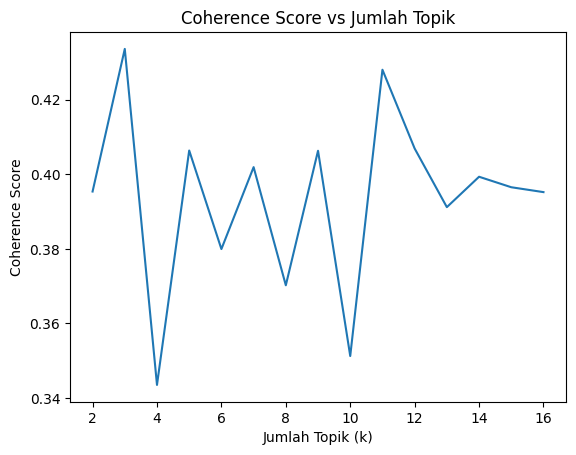

In [ ]:
# Visualisasi Coherence
x = range(2, 17)

plt.plot(x, coherence_values)
plt.xlabel("Jumlah Topik (k)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Jumlah Topik")
plt.show()

In [ ]:
# Pilih k Terbaik
#  k terbaik berdasarkan grafik atau dari nilai tertinggi
optimal_k = x[np.argmax(coherence_values)]
print(f"\nJumlah topik terbaik berdasarkan coherence score adalah: {optimal_k}")


Jumlah topik terbaik berdasarkan coherence score adalah: 3


In [ ]:
# Buat Model LDA Final
lda_model_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=optimal_k,
    random_state=100,
    chunksize=200,
    passes=20,
    alpha='auto',
    per_word_topics=True
)
lda_model_final

In [ ]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Visualisasi Topik dengan pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()  # kalau di Jupyter Notebook
vis = pyLDAvis.gensim_models.prepare(lda_model_final, corpus, id2word)
pyLDAvis.display(vis)

Overall term frequency : Frekuensi istilah secara keseluruhan -> biru

Estimated term frequency within the selected topic : Perkiraan frekuensi istilah dalam topik yang dipilih -> merah

In [ ]:
# Kata Kunci Tiap Topik (Top Words per Topic)
for idx, topic in lda_model_final.show_topics(formatted=False, num_words=10):
    print(f"\nTopik {idx}:")
    print([word for word, _ in topic])


Topik 0:
['mbg', 'uang', 'henti', 'nyawa', 'nol', 'hamil', 'ganti', 'rakyat', 'dapur', 'ribu']

Topik 1:
['makan', 'anak', 'racun', 'sekolah', 'orang', 'gratis', 'tua', 'masak', 'gizi', 'korban']

Topik 2:
['program', 'presiden', 'prabowo', 'ya', 'terima', 'lanjut', 'tolong', 'sehat', 'alhamdulillah', 'kasih']


In [ ]:
for idx, topic in lda_model_final.show_topics(formatted=False, num_words=10):
    print(f"\nTopik {idx}:")
    for word, weight in topic:
        print(f"{word}: {weight:.4f}")


Topik 0:
mbg: 0.1252
uang: 0.0409
henti: 0.0371
nyawa: 0.0240
nol: 0.0207
hamil: 0.0198
ganti: 0.0175
rakyat: 0.0140
dapur: 0.0135
ribu: 0.0105

Topik 1:
makan: 0.1096
anak: 0.1065
racun: 0.0923
sekolah: 0.0662
orang: 0.0514
gratis: 0.0338
tua: 0.0241
masak: 0.0203
gizi: 0.0173
korban: 0.0168

Topik 2:
program: 0.0779
presiden: 0.0714
prabowo: 0.0559
ya: 0.0524
terima: 0.0478
lanjut: 0.0448
tolong: 0.0287
sehat: 0.0265
alhamdulillah: 0.0215
kasih: 0.0212


In [ ]:
# Mendapatkan topik dominan + persentase kontribusi + keywords
def get_dominant_topic(ldamodel, corpus, texts):
    topics_per_doc = []
    perc_contrib = []
    topic_keywords = []

    for i, row in enumerate(ldamodel[corpus]):
        row = sorted(row[0], key=lambda x: (x[1]), reverse=True)

        # ambil topik dominan
        topic_num, prop_topic = row[0]

        # ambil keywords topik tersebut
        keywords = ldamodel.show_topic(topic_num, topn=10)
        keywords = ", ".join([word for word, _ in keywords])

        topics_per_doc.append(topic_num)
        perc_contrib.append(prop_topic)
        topic_keywords.append(keywords)

    return topics_per_doc, perc_contrib, topic_keywords

dominant_topics, perc_contribution, topic_keywords = get_dominant_topic(
    lda_model_final, corpus, texts
)

In [ ]:
mbg_baru['dominant_topic'] = dominant_topics
mbg_baru['perc_contrib'] = perc_contribution
mbg_baru['topic_keywords'] = topic_keywords
mbg_baru

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed,dominant_topic,perc_contrib,topic_keywords
0,"Tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap TIM MBG datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nProgram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????","tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap tim mbg datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nprogram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????",tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan aku sebagai guru setiap tim mbg datang anak anak aku excited luar biasa nunggu kedatanganya program presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan,"['tetapi', 'memang', 'serius', 'untuk', 'kalian', 'yang', 'tidak', 'setuju', 'program', 'ini', 'mencoba', 'deh', 'kalian', 'turut', 'turun', 'di', 'lapangan', 'saya', 'sebagai', 'guru', 'setiap', 'tim', 'mbg', 'datang', 'anak', 'anak', 'saya', 'antusias', 'luar', 'biasa', 'menunggu', 'kedatangannya', 'program', 'presiden', 'ini', 'baik', 'sebenarnya', 'hanya', 'saja', 'terkadang', 'adanya', 'pihak', 'yang', 'menyalahgunakan']","['serius', 'setuju', 'program', 'mencoba', 'turun', 'lapangan', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'menunggu', 'kedatangannya', 'program', 'presiden', 'terkadang', 'menyalahgunakan']","['serius', 'tuju', 'program', 'coba', 'turun', 'lapang', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'tunggu', 'datang', 'program', 'presiden', 'terkadang', 'menyalahgunakan']",1,0.411305,"makan, anak, racun, sekolah, orang, gratis, tua, masak, gizi, korban"
1,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang yang notabene punya uang gaya hedon liburan ke luar negeri mereka gak liat yang begini miris banget,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali,"['terus', 'yang', 'menghujat', 'makanan', 'bergizi', 'adalah', 'orang', 'yang', 'pada', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'kepada', 'luar', 'negeri', 'mereka', 'tidak', 'melihat', 'yang', 'seperti', 'ini', 'memprihatinkan', 'sekali']","['menghujat', 'makanan', 'bergizi', 'orang', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'negeri', 'memprihatinkan']","['hujat', 'makan', 'gizi', 'orang', 'dasar', 'milik', 'uang', 'gaya', 'hedonisme', 'libur', 'negeri', 'prihatin']",1,0.586516,"makan, anak, racun, sekolah, orang, gratis, tua, masak, gizi, korban"
2,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah,makan yang lezat ya adik itu hasil kami melawan anak abah,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu', 'hasil', 'kami', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'lawan', 'anak', 'abah']",1,0.672235,"makan, anak, racun, sekolah, orang, gratis, tua, masak, gizi, korban"
3,"Tolong yaaaa. Yg d

In [ ]:
topic_names = {
    0: "Ketidaksetujuan & Risiko Program",
    1: "Pelaksanaan Program di Sekolah",
    2: "Dukungan terhadap Program"
}

mbg_baru['aspect'] = mbg_baru['dominant_topic'].map(topic_names)
mbg_baru

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed,dominant_topic,perc_contrib,topic_keywords,aspect
0,"Tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap TIM MBG datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nProgram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????","tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan, aku sebagai guru setiap tim mbg datang anak-anak aku excited luar biasa nunggu kedatanganya ????\nprogram presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan ????",tapi emang serius buat kalian yang gak setuju program ini coba deh kalian ikut turun di lapangan aku sebagai guru setiap tim mbg datang anak anak aku excited luar biasa nunggu kedatanganya program presiden ini baik sebenernya hanya saja terkadang ada pihak yang menyalahgunakan,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan,"['tetapi', 'memang', 'serius', 'untuk', 'kalian', 'yang', 'tidak', 'setuju', 'program', 'ini', 'mencoba', 'deh', 'kalian', 'turut', 'turun', 'di', 'lapangan', 'saya', 'sebagai', 'guru', 'setiap', 'tim', 'mbg', 'datang', 'anak', 'anak', 'saya', 'antusias', 'luar', 'biasa', 'menunggu', 'kedatangannya', 'program', 'presiden', 'ini', 'baik', 'sebenarnya', 'hanya', 'saja', 'terkadang', 'adanya', 'pihak', 'yang', 'menyalahgunakan']","['serius', 'setuju', 'program', 'mencoba', 'turun', 'lapangan', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'menunggu', 'kedatangannya', 'program', 'presiden', 'terkadang', 'menyalahgunakan']","['serius', 'tuju', 'program', 'coba', 'turun', 'lapang', 'guru', 'tim', 'mbg', 'anak', 'anak', 'antusias', 'tunggu', 'datang', 'program', 'presiden', 'terkadang', 'menyalahgunakan']",1,0.411305,"makan, anak, racun, sekolah, orang, gratis, tua, masak, gizi, korban",Pelaksanaan Program di Sekolah
1,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang² yang notabene punya uang.. gaya hedon liburan ke luar negeri.. mereka gak liat yang begini².. miris banget,terus yang menghujat makanan bergizi adalah orang yang notabene punya uang gaya hedon liburan ke luar negeri mereka gak liat yang begini miris banget,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali,"['terus', 'yang', 'menghujat', 'makanan', 'bergizi', 'adalah', 'orang', 'yang', 'pada', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'kepada', 'luar', 'negeri', 'mereka', 'tidak', 'melihat', 'yang', 'seperti', 'ini', 'memprihatinkan', 'sekali']","['menghujat', 'makanan', 'bergizi', 'orang', 'dasarnya', 'memiliki', 'uang', 'gaya', 'hedonisme', 'liburan', 'negeri', 'memprihatinkan']","['hujat', 'makan', 'gizi', 'orang', 'dasar', 'milik', 'uang', 'gaya', 'hedonisme', 'libur', 'negeri', 'prihatin']",1,0.586516,"makan, anak, racun, sekolah, orang, gratis, tua, masak, gizi, korban",Pelaksanaan Program di Sekolah
2,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah??,mkn yg enak ya dek itu hasil kami melawan anak abah,makan yang lezat ya adik itu hasil kami melawan anak abah,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu', 'hasil', 'kami', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'melawan', 'anak', 'abah']","['makan', 'lezat', 'ya', 'adik', 'hasil', 'lawan', 'anak', 'abah']",1,0.672235,"makan, anak, racun, se

In [ ]:
mbg_baru.columns

Index(['text', 'case_folding', 'clean_text', 'normalized_text', 'tokens',
       'stopword_removal', 'tokens_stemmed', 'dominant_topic', 'perc_contrib',
       'topic_keywords', 'aspect'],
      dtype='object')

In [ ]:
mbg_baru.dtypes

,0
text,object
case_folding,object
clean_text,object
normalized_text,object
tokens,object
stopword_removal,object
tokens_stemmed,object
dominant_topic,int64
perc_contrib,float32
topic_keywords,object


In [ ]:
# Simpan data setelah preprocessing
mbg_baru.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/aspekmbgada3barubgty.csv', index = False)

In [ ]:
# Hitung jumlah masing-masing aspek
aspect_count= mbg_baru['aspect'].value_counts().sort_index()
print(aspect_count)

aspect
Dukungan terhadap Program           1797
Ketidaksetujuan & Risiko Program    4379
Pelaksanaan Program di Sekolah      2874
Name: count, dtype: int64


<Axes: xlabel='aspect'>

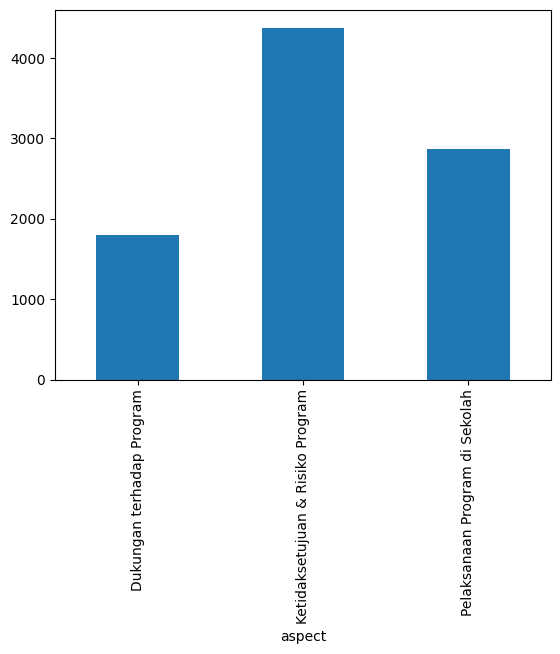

In [ ]:
# Visualisasi
aspect_count.plot(kind='bar')

<Axes: ylabel='count'>

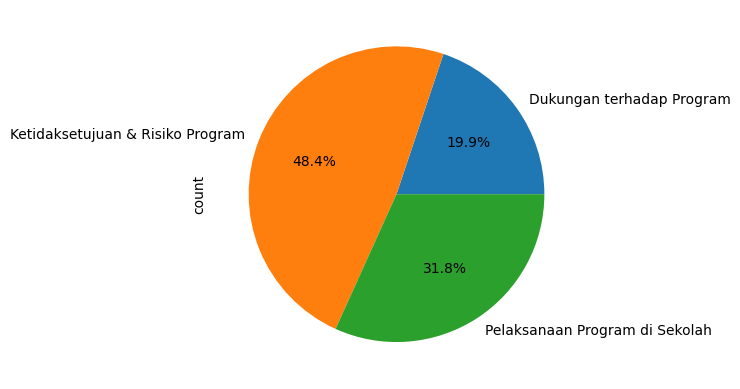

In [ ]:
# Visualisasi Pie-chart beserta persentasenya
aspect_count.plot(kind='pie', autopct='%1.1f%%')


In [ ]:
# Load Dataset After Pre-processing & Ekstraksi Aspek
mbg_baru = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/aspekmbgada3barubgty.csv')
mbg_baru

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed,dominant_topic,perc_contrib,topic_keywords,aspect
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tetapi memang serius untuk kalian yang tidak ...,"['tetapi', 'memang', 'serius', 'untuk', 'kalia...","['serius', 'setuju', 'program', 'mencoba', 'tu...","['serius', 'tuju', 'program', 'coba', 'turun',...",1,0.411305,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,"['terus', 'yang', 'menghujat', 'makanan', 'ber...","['menghujat', 'makanan', 'bergizi', 'orang', '...","['hujat', 'makan', 'gizi', 'orang', 'dasar', '...",1,0.586516,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,makan yang lezat ya adik itu hasil kami melawa...,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu'...","['makan', 'lezat', 'ya', 'adik', 'hasil', 'mel...","['makan', 'lezat', 'ya', 'adik', 'hasil', 'law...",1,0.672235,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...,tolong ya yang di bagian dapur yang untuk mema...,"['tolong', 'ya', 'yang', 'di', 'bagian', 'dapu...","['tolong', 'ya', 'dapur', 'memasak', 'makanan'...","['tolong', 'ya', 'dapur', 'masak', 'makan', 'w...",1,0.400734,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,di lingkungan teman ahli gizi saya banyak yang...,"['di', 'lingkungan', 'teman', 'ahli', 'gizi', ...","['lingkungan', 'teman', 'ahli', 'gizi', 'mengh...","['lingkung', 'teman', 'ahli', 'gizi', 'hujat',...",1,0.682090,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah
...,...,...,...,...,...,...,...,...,...,...,...
9045,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan,benar bapak lanjutkan,"['benar', 'bapak', 'lanjutkan']",['lanjutkan'],['lanjut'],2,0.366662,"program, presiden, prabowo, ya, terima, lanjut...",Dukungan terhadap Program
9046,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...","niatmu baik pak, tapi 15rb tinggal ..... ladan...",niatmu baik pak tapi 15rb tinggal ladang korup...,niatmu baik bapak tetapi 15 ribu rupiah tingg...,"['niatmu', 'baik', 'bapak', 'tetapi', '15', 'r...","['niatmu', '15', 'ribu', 'rupiah', 'tinggal', ...","['niat', '15', 'ribu', 'rupiah', 'tinggal', 'l...",0,0.600759,"mbg, uang, henti, nyawa, nol, hamil, ganti, ra...",Ketidaksetujuan & Risiko Program
9047,cuan cuan,cuan cuan,cuan cuan,untung untung,"['untung', 'untung']","['untung', 'untung']","['untung', 'untung']",0,0.598782,"mbg, uang, henti, nyawa, nol, hamil, ganti, ra...",Ketidaksetujuan & Risiko Program
9048,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg yg keracunan tengok aj yg ...,saya menyukai program mbg yang keracunan lihat...,"['saya', 'menyukai', 'program', 'mbg', 'yang',...","['menyukai', 'program', 'mbg', 'keracunan', 'l...","['suka', 'program', 'mbg', 'racun', 'lihat', '...",1,0.445756,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah


In [ ]:
mbg_baru.columns

Index(['text', 'case_folding', 'clean_text', 'normalized_text', 'tokens',
       'stopword_removal', 'tokens_stemmed', 'dominant_topic', 'perc_contrib',
       'topic_keywords', 'aspect'],
      dtype='object')

In [ ]:
mbg_baru_norspe = mbg_baru[['normalized_text', 'aspect']]
mbg_baru_norspe

,normalized_text,aspect
0,tetapi memang serius untuk kalian yang tidak ...,Pelaksanaan Program di Sekolah
1,terus yang menghujat makanan bergizi adalah or...,Pelaksanaan Program di Sekolah
2,makan yang lezat ya adik itu hasil kami melawa...,Pelaksanaan Program di Sekolah
3,tolong ya yang di bagian dapur yang untuk mema...,Pelaksanaan Program di Sekolah
4,di lingkungan teman ahli gizi saya banyak yang...,Pelaksanaan Program di Sekolah
...,...,...
9045,benar bapak lanjutkan,Dukungan terhadap Program
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...,Ketidaksetujuan & Risiko Program
9047,untung untung,Ketidaksetujuan & Risiko Program
9048,saya menyukai program mbg yang keracunan lihat...,Pelaksanaan Program di Sekolah


In [ ]:
# Simpan csv
mbg_baru_norspe.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/hanyanormalaspek.csv', index = False)

# **Opinion Extraction**

## **Using IndoBERT**
model pre-trained seperti mdhugol/indonesia-bert-sentiment-classification

In [ ]:
mbg_baru = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/normalisasidanaspek.csv', sep = ";")
mbg_baru

,normalized_text,aspect
0,tetapi memang serius untuk kalian yang tidak ...,Pelaksanaan Program di Sekolah
1,terus yang menghujat makanan bergizi adalah or...,Pelaksanaan Program di Sekolah
2,makan yang lezat ya adik itu hasil kami melawa...,Pelaksanaan Program di Sekolah
3,tolong ya yang di bagian dapur yang untuk mema...,Pelaksanaan Program di Sekolah
4,di lingkungan teman ahli gizi saya banyak yang...,Pelaksanaan Program di Sekolah
...,...,...
9045,benar bapak lanjutkan,Dukungan terhadap Program
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...,Ketidaksetujuan dan Risiko Program
9047,untung untung,Ketidaksetujuan dan Risiko Program
9048,saya menyukai program mbg yang keracunan lihat...,Pelaksanaan Program di Sekolah


In [ ]:
# Check missing value
mbg_baru.isnull().sum()

,0
normalized_text,0
aspect,0


In [ ]:
#  Load IndoBERT Sentiment
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

pretrained= "mdhugol/indonesia-bert-sentiment-classification"

model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Contoh
pos_text = "Sangat bahagia hari ini"
neg_text = "Dasar anak sialan!! Kurang ajar!!"

result = sentiment_analysis(pos_text)
status = label_index[result[0]['label']]
score = result[0]['score']
print(f'Text: {pos_text} | Label : {status} ({score * 100:.3f}%)')

result = sentiment_analysis(neg_text)
status = label_index[result[0]['label']]
score = result[0]['score']
print(f'Text: {neg_text} | Label : {status} ({score * 100:.3f}%)')

Text: Sangat bahagia hari ini | Label : positive (98.457%)
Text: Dasar anak sialan!! Kurang ajar!! | Label : negative (97.866%)


In [ ]:
import pandas as pd

# fungsi untuk ambil label & score
def get_sentiment(text):
    try:
        result = sentiment_analysis(text)[0]
        label = label_index[result['label']]
        score = result['score']
        return pd.Series([label, score])
    except:
        return pd.Series([None, None])

# apply ke kolom normalized_text
mbg_baru[['sentiment', 'score']] = mbg_baru['normalized_text'].apply(get_sentiment)

In [ ]:
mbg_baru

,text,case_folding,clean_text,normalized_text,tokens,stopword_removal,tokens_stemmed,dominant_topic,perc_contrib,topic_keywords,aspect,sentiment,score
0,Tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tapi emang serius buat kalian yang gak setuju ...,tetapi memang serius untuk kalian yang tidak ...,"['tetapi', 'memang', 'serius', 'untuk', 'kalia...","['serius', 'setuju', 'program', 'mencoba', 'tu...","['serius', 'tuju', 'program', 'coba', 'turun',...",1,0.411305,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,negative,0.781898
1,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,terus yang menghujat makanan bergizi adalah or...,"['terus', 'yang', 'menghujat', 'makanan', 'ber...","['menghujat', 'makanan', 'bergizi', 'orang', '...","['hujat', 'makan', 'gizi', 'orang', 'dasar', '...",1,0.586516,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,negative,0.995167
2,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,mkn yg enak ya dek itu hasil kami melawan anak...,makan yang lezat ya adik itu hasil kami melawa...,"['makan', 'yang', 'lezat', 'ya', 'adik', 'itu'...","['makan', 'lezat', 'ya', 'adik', 'hasil', 'mel...","['makan', 'lezat', 'ya', 'adik', 'hasil', 'law...",1,0.672235,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,positive,0.970867
3,Tolong yaaaa. Yg di bagian dapur yang buat mas...,tolong yaaaa. yg di bagian dapur yang buat mas...,tolong ya yg di bagian dapur yang buat masak m...,tolong ya yang di bagian dapur yang untuk mema...,"['tolong', 'ya', 'yang', 'di', 'bagian', 'dapu...","['tolong', 'ya', 'dapur', 'memasak', 'makanan'...","['tolong', 'ya', 'dapur', 'masak', 'makan', 'w...",1,0.400734,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,negative,0.978173
4,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,dilingkungan teman ahli giziku banyak yg hujat...,di lingkungan teman ahli gizi saya banyak yang...,"['di', 'lingkungan', 'teman', 'ahli', 'gizi', ...","['lingkungan', 'teman', 'ahli', 'gizi', 'mengh...","['lingkung', 'teman', 'ahli', 'gizi', 'hujat',...",1,0.682090,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,negative,0.994237
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9045,betul pak lanjutkan ??,betul pak lanjutkan ??,betul pak lanjutkan,benar bapak lanjutkan,"['benar', 'bapak', 'lanjutkan']",['lanjutkan'],['lanjut'],2,0.366662,"program, presiden, prabowo, ya, terima, lanjut...",Dukungan terhadap Program,neutral,0.718719
9046,"niatmu baik pak, Tapi 15rb tinggal ..... ladan...","niatmu baik pak, tapi 15rb tinggal ..... ladan...",niatmu baik pak tapi 15rb tinggal ladang korup...,niatmu baik bapak tetapi 15 ribu rupiah tingg...,"['niatmu', 'baik', 'bapak', 'tetapi', '15', 'r...","['niatmu', '15', 'ribu', 'rupiah', 'tinggal', ...","['niat', '15', 'ribu', 'rupiah', 'tinggal', 'l...",0,0.600759,"mbg, uang, henti, nyawa, nol, hamil, ganti, ra...",Ketidaksetujuan & Risiko Program,negative,0.996666
9047,cuan cuan,cuan cuan,cuan cuan,untung untung,"['untung', 'untung']","['untung', 'untung']","['untung', 'untung']",0,0.598782,"mbg, uang, henti, nyawa, nol, hamil, ganti, ra...",Ketidaksetujuan & Risiko Program,positive,0.996030
9048,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg.yg keracunan tengok aj yg ...,aq suka program bmg yg keracunan tengok aj yg ...,saya menyukai program mbg yang keracunan lihat...,"['saya', 'menyukai', 'program', 'mbg', 'yang',...","['menyukai', 'program', 'mbg', 'keracunan', 'l...","['suka', 'program', 'mbg', 'racun', 'lihat', '...",1,0.445756,"makan, anak, racun, sekolah, orang, gratis, tu...",Pelaksanaan Program di Sekolah,positive,0.969477


In [ ]:
mbg_baru["sentiment"].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
# Mengubah Sentiment Label menjadi Int
label2id = {"positive": 0, "neutral": 1, "negative": 2}
mbg_baru["sentiment_int"] = mbg_baru["sentiment"].map(label2id)

In [ ]:
mbg_baru

,normalized_text,aspect,sentiment,score,sentiment_int
0,tetapi memang serius untuk kalian yang tidak ...,Pelaksanaan Program di Sekolah,negative,0.781898,2
1,terus yang menghujat makanan bergizi adalah or...,Pelaksanaan Program di Sekolah,negative,0.995167,2
2,makan yang lezat ya adik itu hasil kami melawa...,Pelaksanaan Program di Sekolah,positive,0.970867,0
3,tolong ya yang di bagian dapur yang untuk mema...,Pelaksanaan Program di Sekolah,negative,0.977749,2
4,di lingkungan teman ahli gizi saya banyak yang...,Pelaksanaan Program di Sekolah,negative,0.994237,2
...,...,...,...,...,...
9045,benar bapak lanjutkan,Dukungan terhadap Program,neutral,0.718719,1
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...,Ketidaksetujuan dan Risiko Program,negative,0.996666,2
9047,untung untung,Ketidaksetujuan dan Risiko Program,positive,0.996030,0
9048,saya menyukai program mbg yang keracunan lihat...,Pelaksanaan Program di Sekolah,positive,0.969477,0


In [ ]:
# Simpan csv
mbg_baru.to_csv('/content/drive/MyDrive/Tugas Akhir/Data/pelabelansentimenbaruya.csv', index = False)

In [ ]:
mbg_baru

,normalized_text,aspect,sentiment,score,sentiment_int
0,tetapi memang serius untuk kalian yang tidak ...,Pelaksanaan Program di Sekolah,negative,0.781898,2
1,terus yang menghujat makanan bergizi adalah or...,Pelaksanaan Program di Sekolah,negative,0.995167,2
2,makan yang lezat ya adik itu hasil kami melawa...,Pelaksanaan Program di Sekolah,positive,0.970867,0
3,tolong ya yang di bagian dapur yang untuk mema...,Pelaksanaan Program di Sekolah,negative,0.977749,2
4,di lingkungan teman ahli gizi saya banyak yang...,Pelaksanaan Program di Sekolah,negative,0.994237,2
...,...,...,...,...,...
9045,benar bapak lanjutkan,Dukungan terhadap Program,neutral,0.718719,1
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...,Ketidaksetujuan dan Risiko Program,negative,0.996666,2
9047,untung untung,Ketidaksetujuan dan Risiko Program,positive,0.996030,0
9048,saya menyukai program mbg yang keracunan lihat...,Pelaksanaan Program di Sekolah,positive,0.969477,0


In [ ]:
# Hitung jumlah masing-masing sentimen untuk tiap aspek
sentiment_count_indb = mbg_baru.groupby(['aspect', 'sentiment_int_indobert']).size().unstack(fill_value=0)

# Tampilkan hasil
print(sentiment_count_indb)

sentiment_int_indobert               0    1     2
aspect                                           
Dukungan terhadap Program         1111  211   475
Ketidaksetujuan & Risiko Program   806  885  2688
Pelaksanaan Program di Sekolah     740  298  1836


In [ ]:
# Hitung jumlah masing-masing sentimen untuk tiap aspek
sentiment_count = mbg_baru.groupby(['aspect', 'sentiment_int']).size().unstack(fill_value=0)

# Tampilkan hasil
print(sentiment_count)

sentiment_int                          0    1     2
aspect                                             
Dukungan terhadap Program           1119  203   475
Ketidaksetujuan dan Risiko Program   807  877  2695
Pelaksanaan Program di Sekolah       744  297  1833


In [ ]:
# Hitung jumlah masing-masing sentimen
sentiment_count_indb = mbg_baru['sentiment_int_indobert'].value_counts().sort_index()
print(sentiment_count_indb)

sentiment_int_indobert
0    2657
1    1394
2    4999
Name: count, dtype: int64


In [ ]:
# Hitung jumlah masing-masing sentimen
sentiment_count = mbg_baru['sentiment_int'].value_counts().sort_index()
print(sentiment_count)

sentiment_int
0    2670
1    1377
2    5003
Name: count, dtype: int64


In [ ]:
# Hitung jumlah masing-masing sentimen
sentiment_counts= mbg_baru.groupby(['sentiment']).size()

# Tampilkan hasil
print(sentiment_counts)

sentiment
negative    5003
neutral     1377
positive    2670
dtype: int64


<Axes: >

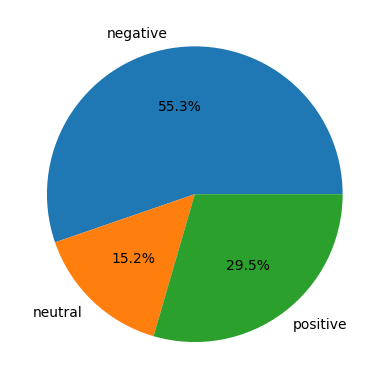

In [ ]:
# Pie Chart
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')

<Axes: >

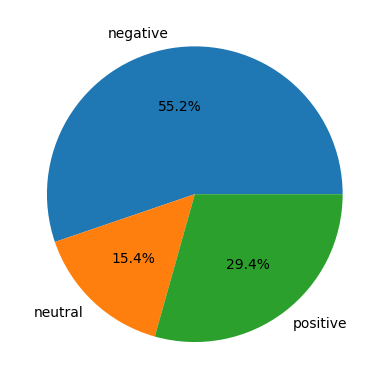

In [ ]:
# Pie Chart
sentiment_count_indb.plot(kind='pie', autopct='%1.1f%%')

In [ ]:
avg_sentiment = mbg_baru.groupby('aspect')['sentiment_int'].mean()
print(avg_sentiment)

aspect
Dukungan terhadap Program             0.641625
Ketidaksetujuan dan Risiko Program    1.431149
Pelaksanaan Program di Sekolah        1.378914
Name: sentiment_int, dtype: float64


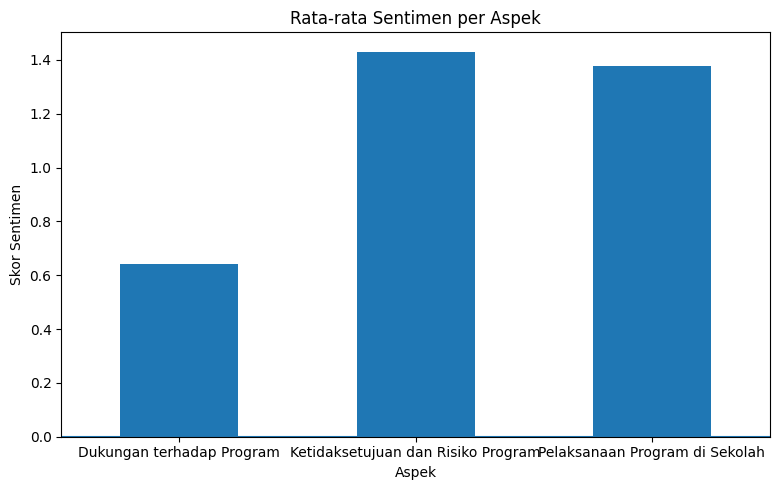

In [ ]:
import matplotlib.pyplot as plt

avg_sentiment.plot(kind='bar', figsize=(8,5))

plt.title('Rata-rata Sentimen per Aspek')
plt.xlabel('Aspek')
plt.ylabel('Skor Sentimen')
plt.axhline(0)  # garis netral

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
sentiment_dan_aspect = mbg_baru.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)
print(sentiment_dan_aspect)

sentiment                           negative  neutral  positive
aspect                                                         
Dukungan terhadap Program                475      203      1119
Ketidaksetujuan dan Risiko Program      2695      877       807
Pelaksanaan Program di Sekolah          1833      297       744


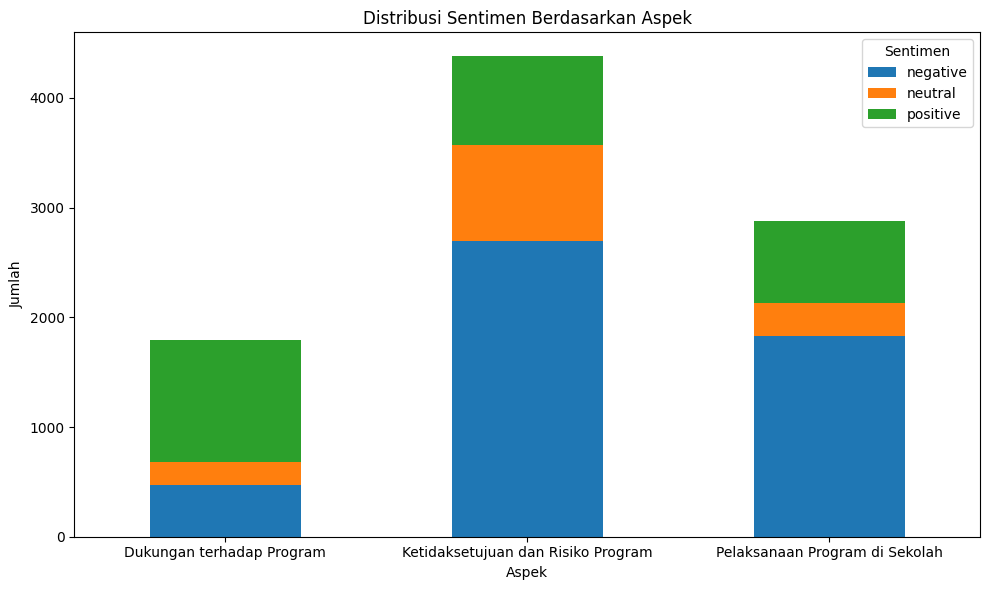

In [ ]:
import matplotlib.pyplot as plt

sentiment_dan_aspect.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Distribusi Sentimen Berdasarkan Aspek')
plt.xlabel('Aspek')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.legend(title='Sentimen')

plt.tight_layout()
plt.show()

# New Section

# **Runtime Keputus, jadi langsung pake data terakhir yang disimpan (udah bersih, ada aspek, dan sentimennya**)

In [ ]:
mbg_baru = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Data/pelabelansentimenbaruya.csv')
mbg_baru

,normalized_text,aspect,sentiment,score,sentiment_int
0,tetapi memang serius untuk kalian yang tidak ...,Pelaksanaan Program di Sekolah,negative,0.781898,2
1,terus yang menghujat makanan bergizi adalah or...,Pelaksanaan Program di Sekolah,negative,0.995167,2
2,makan yang lezat ya adik itu hasil kami melawa...,Pelaksanaan Program di Sekolah,positive,0.970867,0
3,tolong ya yang di bagian dapur yang untuk mema...,Pelaksanaan Program di Sekolah,negative,0.977749,2
4,di lingkungan teman ahli gizi saya banyak yang...,Pelaksanaan Program di Sekolah,negative,0.994237,2
...,...,...,...,...,...
9045,benar bapak lanjutkan,Dukungan terhadap Program,neutral,0.718719,1
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...,Ketidaksetujuan dan Risiko Program,negative,0.996666,2
9047,untung untung,Ketidaksetujuan dan Risiko Program,positive,0.996030,0
9048,saya menyukai program mbg yang keracunan lihat...,Pelaksanaan Program di Sekolah,positive,0.969477,0


In [ ]:
# Cek missing values
mbg_baru.isnull().sum()

,0
normalized_text,0
aspect,0
sentiment,0
score,0
sentiment_int,0


In [ ]:
# Cek tipe data
mbg_baru.dtypes

,0
normalized_text,object
aspect,object
sentiment,object
score,float64
sentiment_int,int64


In [ ]:
# Melihat total sentimen berdasarkan aspek
# Hitung jumlah sentimen per aspek
sentimen_count = mbg_baru.groupby(['aspect', 'sentiment']).size().reset_index(name='jumlah')
print(sentimen_count)

# Atau tampilkan dalam bentuk tabel pivot yang lebih mudah dibaca
sentimen_pivot = mbg_baru.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)
print(sentimen_pivot)

                               aspect sentiment  jumlah
0           Dukungan terhadap Program  negative     475
1           Dukungan terhadap Program   neutral     203
2           Dukungan terhadap Program  positive    1119
3  Ketidaksetujuan dan Risiko Program  negative    2695
4  Ketidaksetujuan dan Risiko Program   neutral     877
5  Ketidaksetujuan dan Risiko Program  positive     807
6      Pelaksanaan Program di Sekolah  negative    1833
7      Pelaksanaan Program di Sekolah   neutral     297
8      Pelaksanaan Program di Sekolah  positive     744
sentiment                           negative  neutral  positive
aspect                                                         
Dukungan terhadap Program                475      203      1119
Ketidaksetujuan dan Risiko Program      2695      877       807
Pelaksanaan Program di Sekolah          1833      297       744


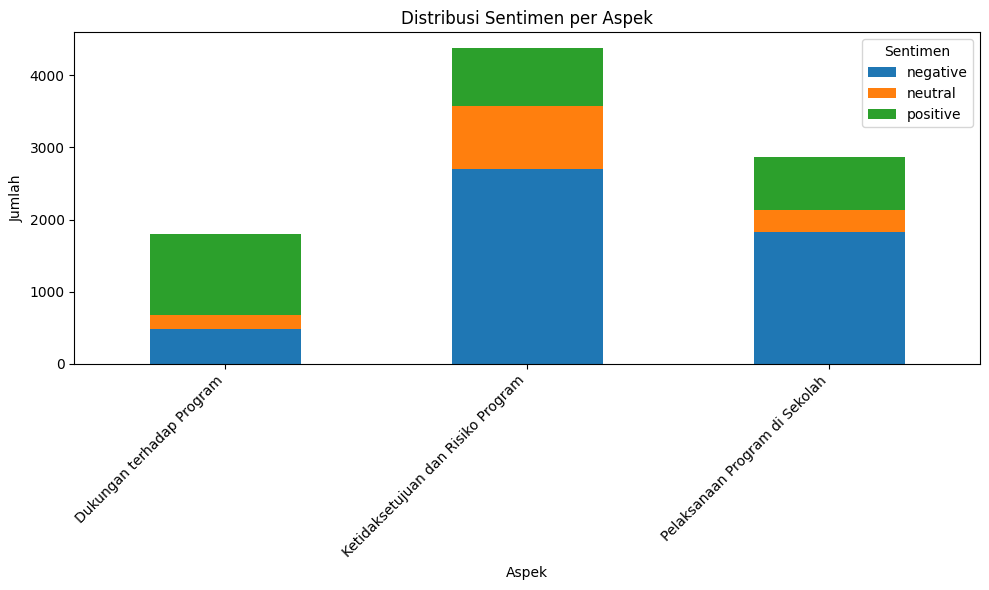

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung frekuensi
sentimen_count = mbg_baru.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

# Plot
sentimen_count.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribusi Sentimen per Aspek')
plt.xlabel('Aspek')
plt.ylabel('Jumlah')
plt.legend(title='Sentimen')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Visualisasi Aspek Per Sentimennya**

sentiment                           negative  neutral  positive
aspect                                                         
Dukungan terhadap Program                475      203      1119
Ketidaksetujuan dan Risiko Program      2695      877       807
Pelaksanaan Program di Sekolah          1833      297       744

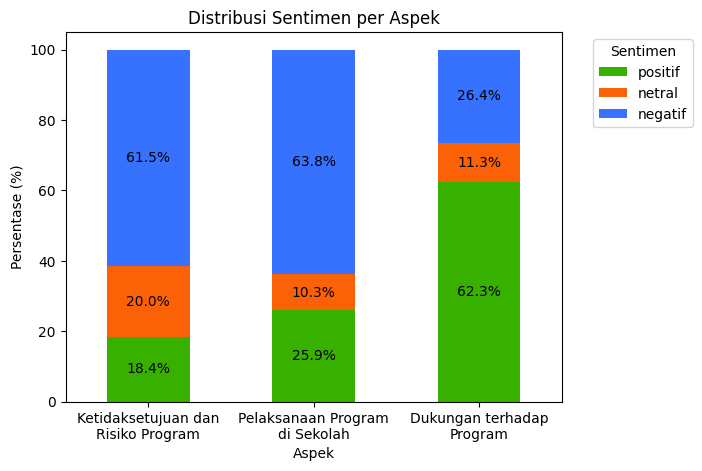

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    'Aspek': [
        'Ketidaksetujuan dan\nRisiko Program',
        'Pelaksanaan Program\ndi Sekolah',
        'Dukungan terhadap\nProgram'
    ],
     'positif': [807, 744, 1119],
    'netral': [877, 297, 203],
    'negatif': [2695, 1833, 475]
}

df = pd.DataFrame(data)
df.set_index('Aspek', inplace=True)

# Ubah ke persen
df_percent = df.div(df.sum(axis=1), axis=0) * 100

# Plot
ax = df_percent.plot(
    kind='bar',
    stacked=True,
    color=['#38b000', '#fb6107', '#3772ff'] # Positif, Netral, Negatif
)

# Label persen
for i in range(len(df_percent)):
    cumulative = 0
    for j, col in enumerate(df_percent.columns):
        value = df_percent.iloc[i, j]
        if value > 5:
            ax.text(i, cumulative + value/2, f"{value:.1f}%", ha='center', va='center')
        cumulative += value

plt.xticks(rotation=0)
plt.ylabel("Persentase (%)")
plt.title("Distribusi Sentimen per Aspek")
plt.legend(title="Sentimen", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# **Split Data**

Data Train: 70%

Data Validasi: 15%

Data Test: 15%

In [ ]:
mbg_baru.columns

Index(['normalized_text', 'aspect', 'sentiment', 'score', 'sentiment_int'], dtype='object')

In [ ]:
# Menggabungkan kolom teks normalisasi dan aspek
mbg_baru['teks_aspek'] = mbg_baru['normalized_text'] + " [SEP] " + mbg_baru['aspect']
mbg_baru['teks_aspek']

,teks_aspek
0,tetapi memang serius untuk kalian yang tidak ...
1,terus yang menghujat makanan bergizi adalah or...
2,makan yang lezat ya adik itu hasil kami melawa...
3,tolong ya yang di bagian dapur yang untuk mema...
4,di lingkungan teman ahli gizi saya banyak yang...
...,...
9045,benar bapak lanjutkan [SEP] Dukungan terhadap ...
9046,niatmu baik bapak tetapi 15 ribu rupiah tingg...
9047,untung untung [SEP] Ketidaksetujuan dan Risiko...
9048,saya menyukai program mbg yang keracunan lihat...


In [ ]:
# Menampilkan seluruh teks tanpa pemotongan
pd.set_option('display.max_colwidth', None)
mbg_baru['teks_aspek'].head(5)

,teks_aspek
0,tetapi memang serius untuk kalian yang tidak setuju program ini mencoba deh kalian turut turun di lapangan saya sebagai guru setiap tim mbg datang anak anak saya antusias luar biasa menunggu kedatangannya program presiden ini baik sebenarnya hanya saja terkadang adanya pihak yang menyalahgunakan [SEP] Pelaksanaan Program di Sekolah
1,terus yang menghujat makanan bergizi adalah orang yang pada dasarnya memiliki uang gaya hedonisme liburan kepada luar negeri mereka tidak melihat yang seperti ini memprihatinkan sekali [SEP] Pelaksanaan Program di Sekolah
2,makan yang lezat ya adik itu hasil kami melawan anak abah [SEP] Pelaksanaan Program di Sekolah
3,tolong ya yang di bagian dapur yang untuk memasak makanan ini untuk semua mua wilayah jangan adanya mengorupsi dana memberikan yang terbaik memberi buah juga jangan pelit jangan makanan basi yang di memberikan karena nanti yang terkena nama buruk juga bapak prabowo bukan kalian oke [SEP] Pelaksanaan Program di Sekolah
4,di lingkungan teman ahli gizi saya banyak yang menghujat saya karena saya menjadi ahli gizi mbg mereka mengatakan menu mbg sangat jauh dari kata ideal padahal mereka tidak mengetahui yang seperti begini mbg bukan untuk anak ibu untuk anak yang membutuhkan [SEP] Pelaksanaan Program di Sekolah


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = mbg_baru['teks_aspek']
y = mbg_baru['sentiment_int']
aspect = mbg_baru['aspect']

X_train, X_temp, y_train, y_temp, aspect_train, aspect_temp = train_test_split(
    X, y, aspect,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test, aspect_val, aspect_test = train_test_split(
    X_temp, y_temp, aspect_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("="*40)
print("DATA SPLIT (ASPEK + SENTIMEN):")
print(f"Total data: {len(X)}")

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print("="*40)

DATA SPLIT (ASPEK + SENTIMEN):
Total data: 9050
Train: 6335 (70.0%)
Validation: 1357 (15.0%)
Test: 1358 (15.0%)


In [ ]:
aspect_train.value_counts()

,count
aspect,
Ketidaksetujuan dan Risiko Program,3070
Pelaksanaan Program di Sekolah,2008
Dukungan terhadap Program,1257


In [ ]:
aspect_val.value_counts()

,count
aspect,
Ketidaksetujuan dan Risiko Program,662
Pelaksanaan Program di Sekolah,417
Dukungan terhadap Program,278


In [ ]:
aspect_test.value_counts()

,count
aspect,
Ketidaksetujuan dan Risiko Program,647
Pelaksanaan Program di Sekolah,449
Dukungan terhadap Program,262


# **Balancing data menggunakan Class Weight**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{np.int64(0): np.float64(1.1298377028714108),
 np.int64(1): np.float64(2.1905255878284926),
 np.int64(2): np.float64(0.6029887683228631)}

In [ ]:
# Cek total data train
from collections import Counter
Counter(y_train)

Counter({2: 3502, 0: 1869, 1: 964})

# **Text Embedding Using IndoBERT**

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load IndoBERT
tokenizer  = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p2')
bert_model = BertModel.from_pretrained('indobenchmark/indobert-base-p2')
bert_model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
num_classes = len(mbg_baru['sentiment_int'].unique())
num_classes

3

In [ ]:
from tqdm import tqdm

def get_embeddings_batched(texts, mode='sequence', batch_size=32):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding ({mode})"):
        batch = texts[i : i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        if mode == 'sequence':
            emb = outputs.last_hidden_state           # (batch, 128, 768)
        elif mode == 'cls':
            emb = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

        all_embeddings.append(emb)

    return torch.cat(all_embeddings, dim=0)

In [ ]:
# EMBEDDING UNTUK CNN & BiLSTM → mode='sequence'
# CNN  : butuh semua token untuk ditangkap pola lokal lewat kernel/filter
# BiLSTM: butuh urutan token untuk diproses satu per satu
# ============================================================
print("Embedding sequence untuk CNN & BiLSTM...")

seq_train = get_embeddings_batched(X_train.tolist(), mode='sequence', batch_size=32)  # (n_train, 128, 768)
seq_val   = get_embeddings_batched(X_val.tolist(),   mode='sequence', batch_size=32)  # (n_val, 128, 768)
seq_test  = get_embeddings_batched(X_test.tolist(),  mode='sequence', batch_size=32)  # (n_test, 128, 768)

print(f"seq_train : {seq_train.shape}")
print(f"seq_val   : {seq_val.shape}")
print(f"seq_test  : {seq_test.shape}")

Embedding sequence untuk CNN & BiLSTM...


Embedding (sequence): 100%|██████████| 43/43 [05:27<00:00,  7.62s/it]


seq_train : torch.Size([6335, 128, 768])
seq_val   : torch.Size([1357, 128, 768])
seq_test  : torch.Size([1358, 128, 768])


In [ ]:
print(f"seq_train : {seq_train.shape}")
print(f"seq_val   : {seq_val.shape}")
print(f"seq_test  : {seq_test.shape}")

seq_train : torch.Size([6335, 128, 768])
seq_val   : torch.Size([1357, 128, 768])
seq_test  : torch.Size([1358, 128, 768])


In [ ]:
# EMBEDDING UNTUK INDOBERT FINE-TUNE → mode='cls'
# BERT sudah merangkum seluruh kalimat di token [CLS]
# Classifier tinggal membaca vektor itu langsung
# ============================================================
print("\nEmbedding CLS untuk IndoBERT...")

cls_train = get_embeddings_batched(X_train.tolist(), mode='cls')  # (n_train, 768)
cls_val   = get_embeddings_batched(X_val.tolist(),   mode='cls')  # (n_val, 768)
cls_test  = get_embeddings_batched(X_test.tolist(),  mode='cls')  # (n_test, 768)

print(f"cls_train : {cls_train.shape}")
print(f"cls_val   : {cls_val.shape}")
print(f"cls_test  : {cls_test.shape}")


Embedding CLS untuk IndoBERT...


Embedding (cls): 100%|██████████| 16/16 [02:01<00:00,  7.62s/it]

cls_train : torch.Size([2310, 768])
cls_val   : torch.Size([495, 768])
cls_test  : torch.Size([496, 768])


In [ ]:
print(f"cls_train : {cls_train.shape}")
print(f"cls_val   : {cls_val.shape}")
print(f"cls_test  : {cls_test.shape}")

cls_train : torch.Size([2310, 768])
cls_val   : torch.Size([495, 768])
cls_test  : torch.Size([496, 768])


In [ ]:
le = LabelEncoder()
le.fit(mbg_baru['sentiment_int'])

y_train_tensor = torch.tensor(le.transform(y_train), dtype=torch.long)
y_val_tensor   = torch.tensor(le.transform(y_val),   dtype=torch.long)
y_test_tensor  = torch.tensor(le.transform(y_test),  dtype=torch.long)

**Melihat Hasil Text Embedding**

In [ ]:
# Lihat hasil tokenizer
sample_text = X_train.iloc[0]

inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    padding='max_length',
    truncation=True,
    max_length=128
)

print("Teks:", sample_text)
print("\nToken:")
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))

print("\nInput IDs:")
print(inputs['input_ids'])

print("\nToken Type IDs (segment):")
print(inputs['token_type_ids'])

print("\nAttention Mask:")
print(inputs['attention_mask'])

Teks: ini masalah nyawa manusia prabowo [SEP] Ketidaksetujuan dan Risiko Program

Token:
['[CLS]', 'ini', 'masalah', 'nyawa', 'manusia', 'prabowo', '[SEP]', '[UNK]', 'dan', '[UNK]', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]',

In [ ]:
# Ambil token embedding (word embedding)

bert_model.embeddings.word_embeddings

word_embeddings = bert_model.embeddings.word_embeddings(inputs['input_ids'])

print("Word Embedding shape:", word_embeddings.shape)
# (1, max_length, 768)

print("\nContoh embedding token pertama:")
print(word_embeddings[0][0][:10])  # 10 dimensi pertama


Word Embedding shape: torch.Size([1, 128, 768])

Contoh embedding token pertama:
tensor([-0.0251,  0.0253, -0.0135, -0.0119,  0.0311, -0.0078, -0.0122,  0.0172,
        -0.0120, -0.0090], grad_fn=<SliceBackward0>)


In [ ]:
# Ambil position embedding
position_ids = torch.arange(inputs['input_ids'].size(1)).unsqueeze(0)

position_embeddings = bert_model.embeddings.position_embeddings(position_ids)
position_embeddings

tensor([[[-0.0061, -0.0206,  0.0247,  ..., -0.0403,  0.0012, -0.0150],
         [ 0.0099,  0.0070, -0.0003,  ..., -0.0066,  0.0031, -0.0087],
         [-0.0057, -0.0005,  0.0030,  ..., -0.0098,  0.0102, -0.0066],
         ...,
         [-0.0030, -0.0015, -0.0181,  ..., -0.0089, -0.0051,  0.0138],
         [-0.0043,  0.0158, -0.0323,  ..., -0.0430, -0.0013,  0.0053],
         [-0.0120,  0.0139, -0.0414,  ..., -0.0469, -0.0105,  0.0248]]],
       grad_fn=<EmbeddingBackward0>)

In [ ]:
print("Position Embedding shape:", position_embeddings.shape)

Position Embedding shape: torch.Size([1, 128, 768])


In [ ]:
# Segment Embedding
segment_embeddings = bert_model.embeddings.token_type_embeddings(inputs['token_type_ids'])

print("Segment Embedding shape:", segment_embeddings.shape)

Segment Embedding shape: torch.Size([1, 128, 768])


In [ ]:
# Gabungan embedding -> embedding = token + position + segment
final_embedding = word_embeddings + position_embeddings + segment_embeddings

print("Final Embedding shape:", final_embedding.shape)

Final Embedding shape: torch.Size([1, 128, 768])


In [ ]:
def tampilkan_embedding_dari_data(index=0, max_length=40):
    text = X_train.iloc[index]

    inputs = tokenizer(
        text,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=max_length
    )

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    input_ids = inputs['input_ids'][0].tolist()
    token_type_ids = inputs['token_type_ids'][0].tolist()
    attention_mask = inputs['attention_mask'][0].tolist()
    position_ids = list(range(1, len(input_ids)+1))

    print("=== ORIGINAL ===")
    print(text)

    print("\n=== TOKEN KHUSUS ===")
    print("[CLS] +", text, "+ [SEP]")

    print("\n=== JUMLAH TOKEN ===")
    print(len(tokens))

    print("\n=== WORD TOKENIZING ===")
    print(tokens)

    print("\n=== TOKEN EMBEDDING (input_ids) ===")
    print(input_ids)

    print("\n=== SEGMENT EMBEDDING ===")
    print(token_type_ids)

    print("\n=== POSITION EMBEDDING ===")
    print(position_ids)

    print("\n=== ATTENTION MASK ===")
    print(attention_mask)

In [ ]:
tampilkan_embedding_dari_data(index=0)

=== ORIGINAL ===
ini masalah nyawa manusia prabowo [SEP] Ketidaksetujuan dan Risiko Program

=== TOKEN KHUSUS ===
[CLS] + ini masalah nyawa manusia prabowo [SEP] Ketidaksetujuan dan Risiko Program + [SEP]

=== JUMLAH TOKEN ===
40

=== WORD TOKENIZING ===
['[CLS]', 'ini', 'masalah', 'nyawa', 'manusia', 'prabowo', '[SEP]', '[UNK]', 'dan', '[UNK]', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

=== TOKEN EMBEDDING (input_ids) ===
[2, 92, 805, 9619, 666, 11283, 3, 1, 41, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== SEGMENT EMBEDDING ===
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== POSITION EMBEDDING ===
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,

In [ ]:
tampilkan_embedding_dari_data(index=10)

=== ORIGINAL ===
semangat ibu guru dan anak kuh [SEP] Pelaksanaan Program di Sekolah

=== TOKEN KHUSUS ===
[CLS] + semangat ibu guru dan anak kuh [SEP] Pelaksanaan Program di Sekolah + [SEP]

=== JUMLAH TOKEN ===
40

=== WORD TOKENIZING ===
['[CLS]', 'semangat', 'ibu', 'guru', 'dan', 'anak', 'kuh', '[SEP]', '[UNK]', '[UNK]', 'di', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

=== TOKEN EMBEDDING (input_ids) ===
[2, 2941, 1066, 960, 41, 436, 7366, 3, 1, 1, 26, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== SEGMENT EMBEDDING ===
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== POSITION EMBEDDING ===
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1

In [ ]:
tampilkan_embedding_dari_data(index=3)

=== ORIGINAL ===
omong kosong [SEP] Ketidaksetujuan dan Risiko Program

=== TOKEN KHUSUS ===
[CLS] + omong kosong [SEP] Ketidaksetujuan dan Risiko Program + [SEP]

=== JUMLAH TOKEN ===
40

=== WORD TOKENIZING ===
['[CLS]', 'omong', 'kosong', '[SEP]', '[UNK]', 'dan', '[UNK]', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

=== TOKEN EMBEDDING (input_ids) ===
[2, 15505, 4986, 3, 1, 41, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== SEGMENT EMBEDDING ===
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== POSITION EMBEDDING ===
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2

In [ ]:
def tampilkan_beberapa_embedding(n=15, max_length=40):
    for idx in range(n):
        text = X_train.iloc[idx]

        inputs = tokenizer(
            text,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=max_length
        )

        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        input_ids = inputs['input_ids'][0].tolist()
        token_type_ids = inputs['token_type_ids'][0].tolist()
        position_ids = list(range(1, len(input_ids)+1))

        print(f"\n================= DATA KE-{idx+1} =================")

        print("\nOriginal")
        print(text)

        print("\nToken Khusus")
        print("[CLS] +", text, "+ [SEP]")

        print("\nJumlah Token")
        print(len(tokens))

        print("\nWord Tokenizing")
        print(tokens)

        print("\nToken Embedding")
        print(input_ids)

        print("\nSegmen Embedding")
        print(token_type_ids)

        print("\nPosition Embedding")
        print(position_ids)

In [ ]:
tampilkan_beberapa_embedding(n=15)


================= DATA KE-1 =================

Original
ini masalah nyawa manusia prabowo [SEP] Ketidaksetujuan dan Risiko Program

Token Khusus
[CLS] + ini masalah nyawa manusia prabowo [SEP] Ketidaksetujuan dan Risiko Program + [SEP]

Jumlah Token
40

Word Tokenizing
['[CLS]', 'ini', 'masalah', 'nyawa', 'manusia', 'prabowo', '[SEP]', '[UNK]', 'dan', '[UNK]', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Token Embedding
[2, 92, 805, 9619, 666, 11283, 3, 1, 41, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Segmen Embedding
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Position Embedding
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 

# **ABSA**

## **Klasifikasi Sentimen**

##**CNN**

Epoch = 10

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input

# Konversi ke numpy
X_train_seq_cnn = seq_train.numpy()  # (n_train, 128, 768)
X_val_seq_cnn   = seq_val.numpy()    # (n_val, 128, 768)
X_test_seq_cnn  = seq_test.numpy()   # (n_test, 128, 768)

# Model CNN
num_classes = len(np.unique(y_train))

model_cnn = Sequential([
    Input(shape=(128, 768)),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_model_cnn = model_cnn.fit(
    X_train_seq_cnn, y_train,
    validation_data=(X_val_seq_cnn, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7361 - loss: 0.7312 - val_accuracy: 0.8121 - val_loss: 0.4550
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8292 - loss: 0.4031 - val_accuracy: 0.8268 - val_loss: 0.4199
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8729 - loss: 0.3082 - val_accuracy: 0.8416 - val_loss: 0.4102
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8826 - loss: 0.2827 - val_accuracy: 0.8467 - val_loss: 0.3844
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8999 - loss: 0.2449 - val_accuracy: 0.8290 - val_loss: 0.4793
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9099 - loss: 0.1973 - val_accuracy: 0.8570 - val_loss: 0.4182
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9288 - loss: 0.1736 - val_accuracy: 0.8511 - val_loss: 0.4898
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9383 - loss: 0.1492 - val_acc

In [ ]:
# Classification Report Aspek Menyeluruh Data Test
from sklearn.metrics import classification_report
import numpy as np

y_pred_cnn_sent_all = np.argmax(
    model_cnn.predict(X_test_seq_cnn),
    axis=1
)

print(classification_report(
    y_test,
    y_pred_cnn_sent_all,
    digits=4
))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
              precision    recall  f1-score   support

           0     0.8878    0.8878    0.8878       401
           1     0.7339    0.8301    0.7790       206
           2     0.9185    0.8855    0.9017       751

    accuracy                         0.8778      1358
   macro avg     0.8467    0.8678    0.8562      1358
weighted avg     0.8814    0.8778    0.8790      1358



In [ ]:
# Prediksi
y_pred_cnn = np.argmax(model_cnn.predict(X_test_seq_cnn), axis=1)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([0, 0, 1, ..., 0, 2, 1])

In [ ]:
from sklearn.metrics import confusion_matrix

cm_cnn_sent = confusion_matrix(y_test, y_pred_cnn)
print(cm_cnn_sent)

[[356  15  30]
 [  6 171  29]
 [ 39  47 665]]


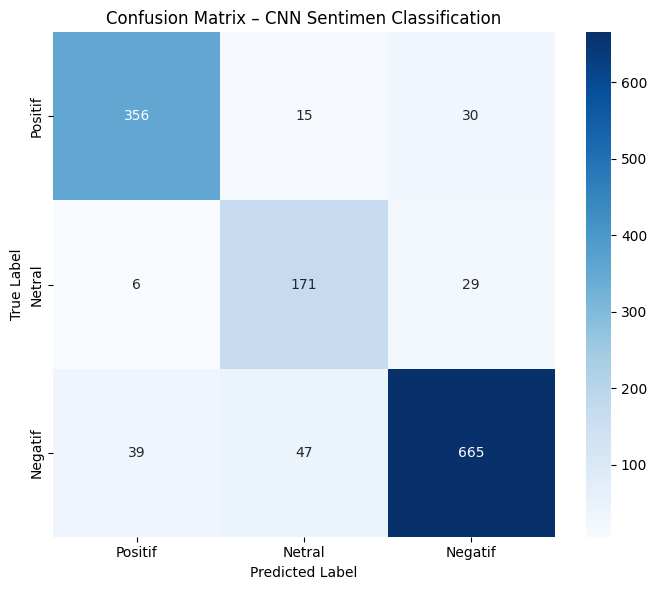

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define sentiment names for the plot
sentiment_names = [
    'Positif',
    'Netral',
    'Negatif'
]

cm_aspect_cnn = confusion_matrix(
    y_test,
    y_pred_cnn
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_cnn_sent,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sentiment_names,
    yticklabels=sentiment_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN Sentimen Classification")
plt.tight_layout()
plt.show()

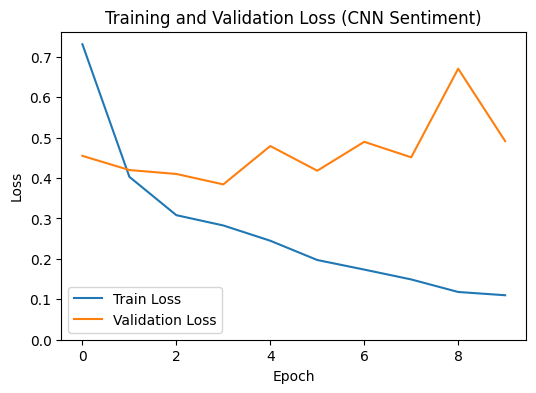

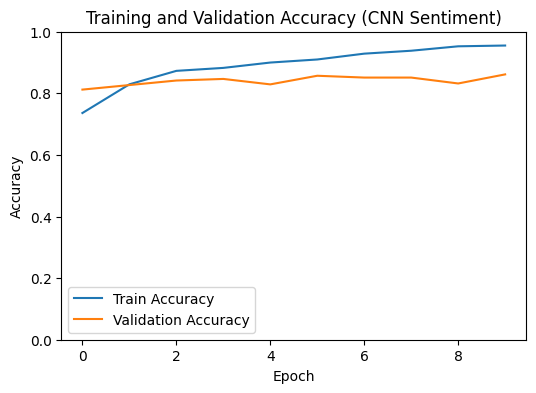

In [ ]:
# Plot Loss (rentang dinamis tapi minimal dari 0)
plt.figure(figsize=(6, 4))
plt.plot(history_model_cnn.history['loss'], label='Train Loss')
plt.plot(history_model_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (CNN Sentiment)')
plt.legend()
plt.ylim(bottom=0)  # ← batas bawah 0, batas atas otomatis
plt.show()

# Plot Akurasi (rentang 0-1)
plt.figure(figsize=(6, 4))
plt.plot(history_model_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy (CNN Sentiment)')
plt.legend()
plt.ylim(0, 1.0)  # ← akurasi pasti antara 0-1
plt.show()

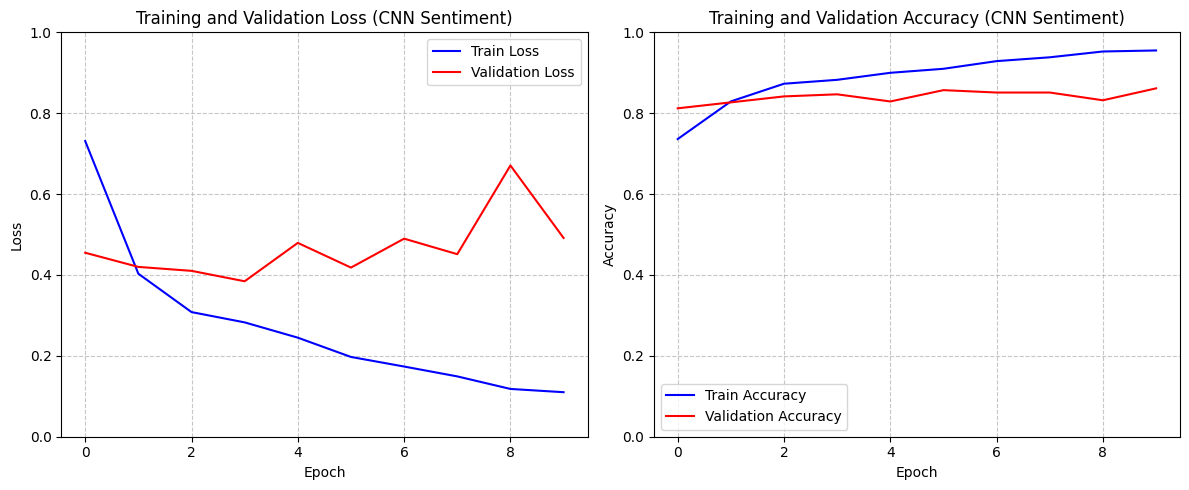

In [ ]:
# Plot Loss dan Akurasi Bersebelahan (1 gambar, 2 subplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Loss
ax1.plot(history_model_cnn.history['loss'], label='Train Loss', color='blue')
ax1.plot(history_model_cnn.history['val_loss'], label='Validation Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss (CNN Sentiment)')
ax1.set_ylim(0, 1.0)  # rentang Y 0-1
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Akurasi
ax2.plot(history_model_cnn.history['accuracy'], label='Train Accuracy', color='blue')
ax2.plot(history_model_cnn.history['val_accuracy'], label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy (CNN Sentiment)')
ax2.set_ylim(0, 1.0)  # rentang Y 0-1
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Layout rapi
plt.tight_layout()
plt.show()

**Evaluasi Model untuk Data Train, Validasi, dan Testing**

In [ ]:
# Evaluasi Data Train CNN-Aspek
y_pred_train_cnn = np.argmax(
    model_cnn.predict(X_train_seq_cnn),
    axis=1
)

print("Classification Report - Train")
print(classification_report(
    y_train,
    y_pred_train_cnn,
    digits=4
))

198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Classification Report - Train
              precision    recall  f1-score   support

           0     0.9740    0.9834    0.9787      1869
           1     0.9487    0.9969    0.9722       964
           2     0.9913    0.9723    0.9817      3502

    accuracy                         0.9793      6335
   macro avg     0.9713    0.9842    0.9775      6335
weighted avg     0.9797    0.9793    0.9794      6335



In [ ]:
# Evaluasi Data Validasi CNN-Aspek
y_pred_val_cnn = np.argmax(
    model_cnn.predict(X_val_seq_cnn),
    axis=1
)

print("Classification Report - Validation")
print(classification_report(
    y_val,
    y_pred_val_cnn,
    digits=4
))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Classification Report - Validation
              precision    recall  f1-score   support

           0     0.8430    0.8725    0.8575       400
           1     0.7197    0.8309    0.7713       207
           2     0.9205    0.8640    0.8913       750

    accuracy                         0.8615      1357
   macro avg     0.8277    0.8558    0.8400      1357
weighted avg     0.8670    0.8615    0.8630      1357



##**BiLSTM**

**Yang bawah ini normalnya, cuma dikecilin bagian ukuran layernya, ga overfitting di epoch ke-6**

**Model ini yang aku coba**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Konversi ke numpy
X_train_seq_bilstm = seq_train.numpy()  # (n_train, 128, 768)
X_val_seq_bilstm   = seq_val.numpy()    # (n_val, 128, 768)
X_test_seq_bilstm  = seq_test.numpy()   # (n_test, 128, 768)

# Model BiLSTM
num_classes = len(np.unique(y_train))

model_bilstm = Sequential([
    Bidirectional(
        LSTM(128, return_sequences=False),
        input_shape=(128, 768)  # ← pindahkan input_shape ke sini
    ),
    Dropout(0.5),  # ← hanya 1 dropout, hapus yang satunya
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_bilstm.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_model_bilstm = model_bilstm.fit(
    X_train_seq_bilstm,
    y_train,
    validation_data=(X_val_seq_bilstm, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6736 - loss: 0.7263 - val_accuracy: 0.7878 - val_loss: 0.5238
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8066 - loss: 0.4728 - val_accuracy: 0.7797 - val_loss: 0.5281
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8324 - loss: 0.3859 - val_accuracy: 0.8534 - val_loss: 0.3588
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8587 - loss: 0.3405 - val_accuracy: 0.8018 - val_loss: 0.5006
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8740 - loss: 0.2859 - val_accuracy: 0.8629 - val_loss: 0.3517
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8865 - loss: 0.2540 - val_accuracy: 0.8688 - val_loss: 0.3476
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9013 - loss: 0.2282 - val_accuracy: 0.8659 - val_loss: 0.3410
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9155 - loss: 0.1886 - val_acc

In [ ]:
test_loss, test_acc = model_bilstm.evaluate(
    X_test_seq_bilstm,
    y_test,
    verbose=0
)

print("Test Accuracy (BiLSTM – Sentimen):", test_acc)


Test Accuracy (BiLSTM – Sentimen): 0.8880707025527954


In [ ]:
import numpy as np

y_pred_bilstm = np.argmax(
   model_bilstm.predict(X_test_seq_bilstm),
    axis=1
)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_bilstm,
    digits=4
))


              precision    recall  f1-score   support

           0     0.8784    0.8828    0.8806       401
           1     0.7773    0.8641    0.8184       206
           2     0.9284    0.8975    0.9127       751

    accuracy                         0.8881      1358
   macro avg     0.8614    0.8814    0.8705      1358
weighted avg     0.8907    0.8881    0.8889      1358



In [ ]:
from sklearn.metrics import confusion_matrix

cm_bilstm = confusion_matrix(
    y_test,
    y_pred_bilstm
)
cm_bilstm

array([[354,  15,  32],
       [  8, 178,  20],
       [ 41,  36, 674]])

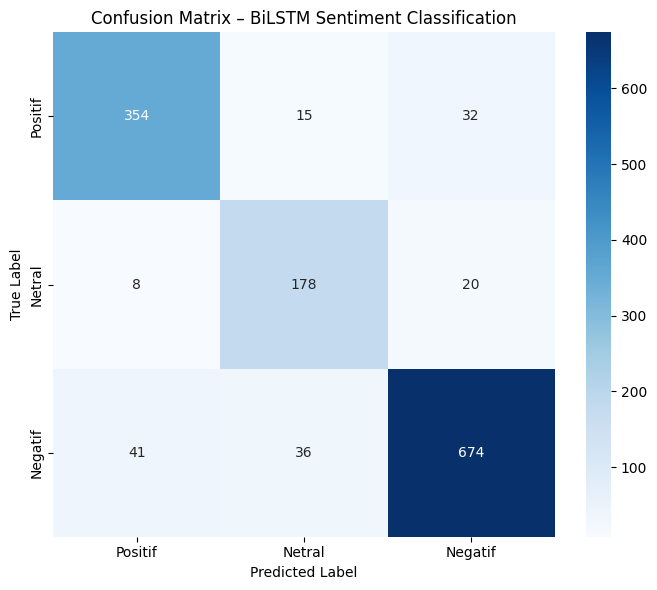

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping nama sentimen
sentiment_names = [
    'Positif',
    'Netral',
    'Negatif'
]

cm_bilstm = confusion_matrix(
    y_test,
    y_pred_bilstm
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_bilstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sentiment_names,
    yticklabels=sentiment_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – BiLSTM Sentiment Classification")
plt.tight_layout()
plt.show()

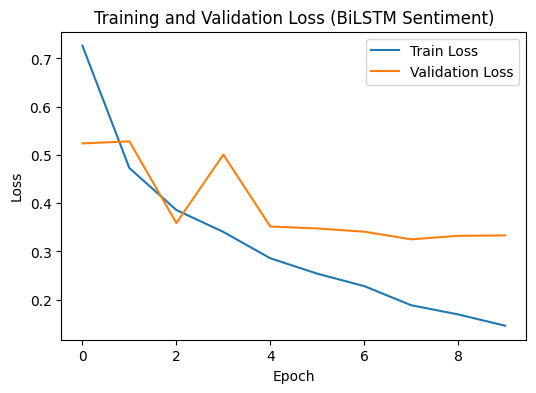

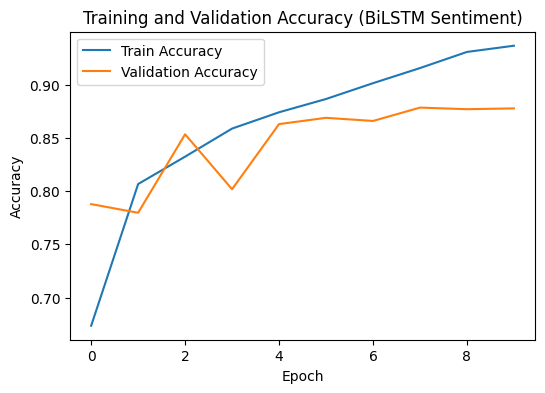

In [ ]:
# Plot Loss dan Akurasi
# Loss
plt.figure(figsize=(6, 4))
plt.plot(history_model_bilstm.history['loss'], label='Train Loss')
plt.plot(history_model_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (BiLSTM Sentiment)')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history_model_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy (BiLSTM Sentiment)')
plt.legend()
plt.show()

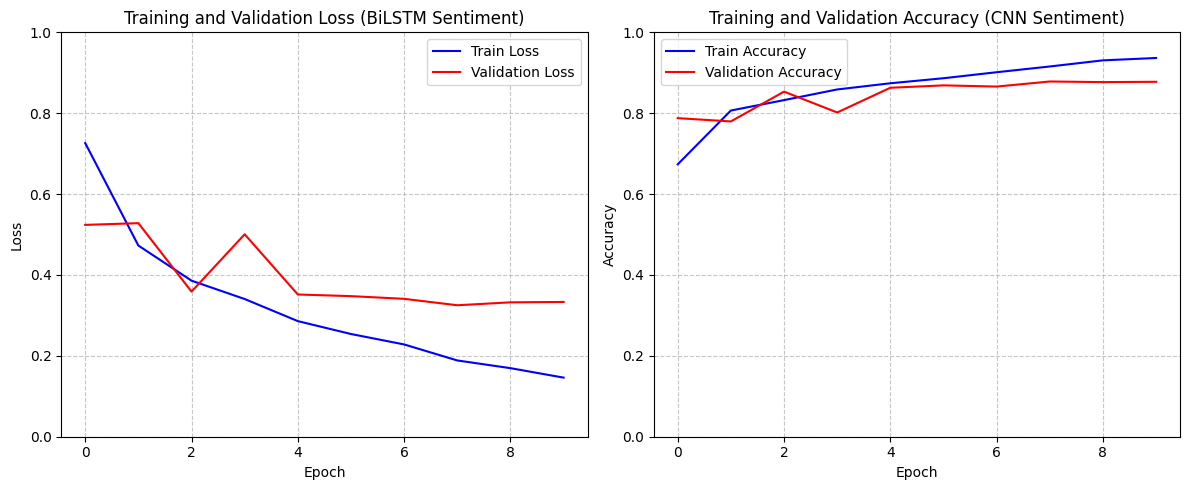

In [ ]:
# Plot Loss dan Akurasi Bersebelahan (1 gambar, 2 subplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Loss
ax1.plot(history_model_bilstm.history['loss'], label='Train Loss', color='blue')
ax1.plot(history_model_bilstm.history['val_loss'], label='Validation Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss (BiLSTM Sentiment)')
ax1.set_ylim(0, 1.0)  # rentang Y 0-1
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Akurasi
ax2.plot(history_model_bilstm.history['accuracy'], label='Train Accuracy', color='blue')
ax2.plot(history_model_bilstm.history['val_accuracy'], label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy (CNN Sentiment)')
ax2.set_ylim(0, 1.0)  # rentang Y 0-1
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Layout rapi
plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi Data Train
import numpy as np

y_pred_bilstm_train = np.argmax(
   model_bilstm.predict(X_train_seq_bilstm),
    axis=1
)
from sklearn.metrics import classification_report

print(classification_report(
    y_train,
    y_pred_bilstm_train,
    digits=4
))

198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

           0     0.9704    0.9658    0.9681      1869
           1     0.9246    0.9927    0.9575       964
           2     0.9814    0.9640    0.9726      3502

    accuracy                         0.9689      6335
   macro avg     0.9588    0.9742    0.9661      6335
weighted avg     0.9695    0.9689    0.9690      6335



In [ ]:
# Evaluasi Data Validasi
import numpy as np

y_pred_bilstm_val = np.argmax(
   model_bilstm.predict(X_val_seq_bilstm),
    axis=1
)
from sklearn.metrics import classification_report

print(classification_report(
    y_val,
    y_pred_bilstm_val,
    digits=4
))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0     0.8903    0.8725    0.8813       400
           1     0.7387    0.7923    0.7646       207
           2     0.9125    0.9040    0.9082       750

    accuracy                         0.8777      1357
   macro avg     0.8472    0.8563    0.8514      1357
weighted avg     0.8795    0.8777    0.8784      1357



# **Klasifikasi Berdasarkan Aspek**

## **CNN**

In [ ]:
# Prediksi
y_pred_cnn = np.argmax(model_cnn.predict(X_test_seq_cnn), axis=1)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
# =============================
# EVALUASI PER ASPEK
# =============================
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Gabungkan jadi dataframe biar rapi
df_eval_cnn = pd.DataFrame({
    'aspect': aspect_test.values,
    'y_true': y_test.values,
    'y_pred': y_pred_cnn
})

# Loop tiap aspek
for asp in df_eval_cnn['aspect'].unique():
    print(f"\n===== ASPEK: {asp} =====")
    subset = df_eval_cnn[df_eval_cnn['aspect'] == asp]

    print("Jumlah data:", len(subset))
    print("Accuracy:", accuracy_score(subset['y_true'], subset['y_pred']))
    print(classification_report(subset['y_true'], subset['y_pred'], digits=4))


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
Jumlah data: 647
Accuracy: 0.8825347758887172
              precision    recall  f1-score   support

           0     0.8571    0.8205    0.8384       117
           1     0.7905    0.8731    0.8298       134
           2     0.9251    0.9040    0.9144       396

    accuracy                         0.8825       647
   macro avg     0.8576    0.8659    0.8609       647
weighted avg     0.8849    0.8825    0.8832       647


===== ASPEK: Dukungan terhadap Program =====
Jumlah data: 262
Accuracy: 0.9122137404580153
              precision    recall  f1-score   support

           0     0.9578    0.9636    0.9607       165
           1     0.7037    0.7037    0.7037        27
           2     0.8841    0.8714    0.8777        70

    accuracy                         0.9122       262
   macro avg     0.8485    0.8463    0.8474       262
weighted avg     0.9119    0.9122    0.9121       262


===== ASPEK: Pelaksanaan Program di Sekolah 

In [ ]:
labels = sorted(df_eval_cnn['y_true'].unique())

for asp in df_eval_cnn['aspect'].unique():
    print(f"\n===== ASPEK: {asp} =====")
    subset = df_eval_cnn[df_eval_cnn['aspect'] == asp]

    cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=labels)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
    0    1    2
0  96    6   15
1   3  117   14
2  13   25  358

===== ASPEK: Dukungan terhadap Program =====
     0   1   2
0  159   4   2
1    2  19   6
2    5   4  61

===== ASPEK: Pelaksanaan Program di Sekolah =====
     0   1    2
0  101   5   13
1    1  35    9
2   21  18  246


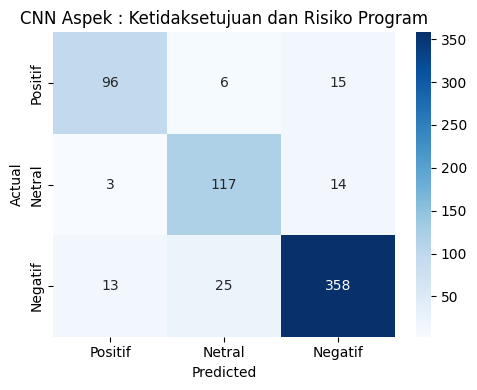

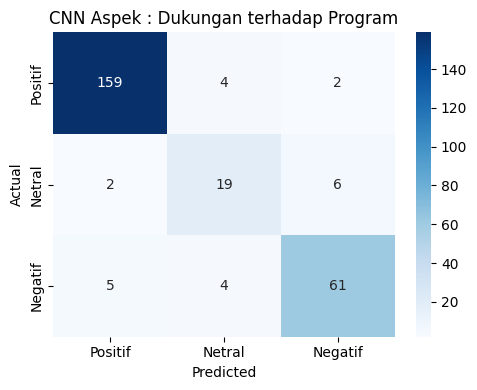

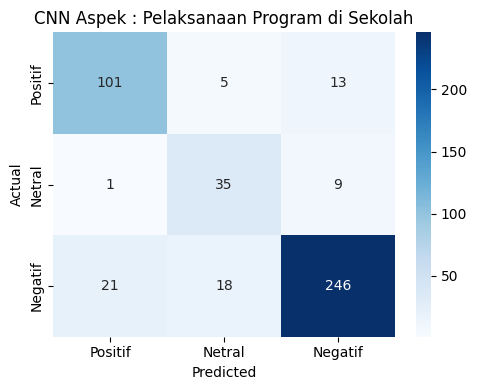

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# mapping label
label_map = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}

labels = sorted(df_eval_cnn['y_true'].unique())
label_names = [label_map[l] for l in labels]

for asp in df_eval_cnn['aspect'].unique():
    subset = df_eval_cnn[df_eval_cnn['aspect'] == asp]
    cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=labels)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f'CNN Aspek : {asp}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## **BiLSTM**

In [ ]:
# Prediksi
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test_seq_bilstm), axis=1)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [ ]:
# EVALUASI PER ASPEK
# =============================
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Gabungkan jadi dataframe biar rapi
df_eval_bilstm = pd.DataFrame({
    'aspect': aspect_test.values,
    'y_true': y_test.values,
    'y_pred': y_pred_bilstm
})

# Loop tiap aspek
for asp in df_eval_bilstm['aspect'].unique():
    print(f"\n===== ASPEK: {asp} =====")
    subset = df_eval_bilstm[df_eval_bilstm['aspect'] == asp]

    print("Jumlah data:", len(subset))
    print("Accuracy:", accuracy_score(subset['y_true'], subset['y_pred']))
    print(classification_report(subset['y_true'], subset['y_pred'], digits=4))


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
Jumlah data: 647
Accuracy: 0.8794435857805255
              precision    recall  f1-score   support

           0     0.7983    0.8120    0.8051       117
           1     0.7857    0.9030    0.8403       134
           2     0.9439    0.8914    0.9169       396

    accuracy                         0.8794       647
   macro avg     0.8426    0.8688    0.8541       647
weighted avg     0.8848    0.8794    0.8808       647


===== ASPEK: Dukungan terhadap Program =====
Jumlah data: 262
Accuracy: 0.9198473282442748
              precision    recall  f1-score   support

           0     0.9578    0.9636    0.9607       165
           1     0.7500    0.7778    0.7636        27
           2     0.8971    0.8714    0.8841        70

    accuracy                         0.9198       262
   macro avg     0.8683    0.8709    0.8695       262
weighted avg     0.9202    0.9198    0.9199       262


===== ASPEK: Pelaksanaan Program di Sekolah 

In [ ]:
labels = sorted(df_eval_bilstm['y_true'].unique())

for asp in df_eval_bilstm['aspect'].unique():
    print(f"\n===== ASPEK: {asp} =====")
    subset = df_eval_bilstm[df_eval_bilstm['aspect'] == asp]

    cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=labels)

    cm_df_bilstm = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df_bilstm)


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
    0    1    2
0  95   10   12
1   4  121    9
2  20   23  353

===== ASPEK: Dukungan terhadap Program =====
     0   1   2
0  159   2   4
1    3  21   3
2    4   5  61

===== ASPEK: Pelaksanaan Program di Sekolah =====
     0   1    2
0  100   3   16
1    1  36    8
2   17   8  260


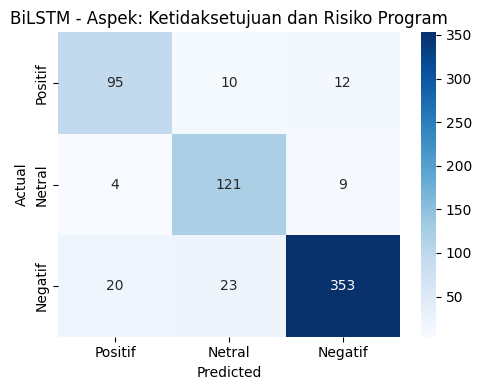

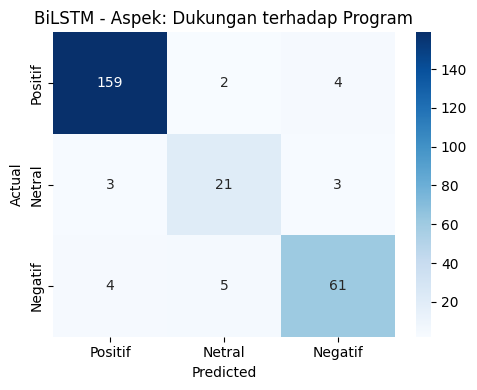

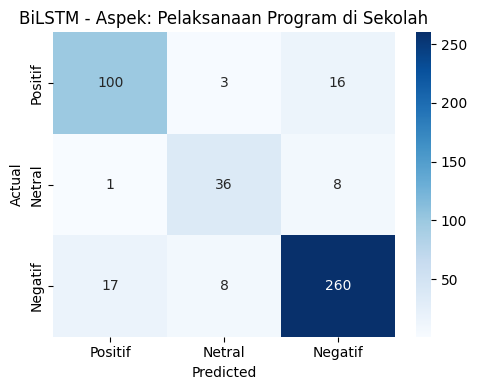

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# mapping label
label_map = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}

labels = sorted(df_eval_bilstm['y_true'].unique())
label_names = [label_map[l] for l in labels]

for asp in df_eval_bilstm['aspect'].unique():
    subset = df_eval_bilstm[df_eval_bilstm['aspect'] == asp]
    cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=labels)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f'BiLSTM - Aspek: {asp}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

 # **INDOBERT TERBARU**

## **Klasfikasi Sentimen**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# 1. Definisi Model IndoBERT generik untuk klasifikasi
class IndoBERTClassifier(nn.Module):
    def __init__(self, model_name="indobenchmark/indobert-base-p2", num_classes=5, dropout=0.3):
        super(IndoBERTClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Mengambil pooled_output untuk klasifikasi (representasi CLS token)
        pooled_output = outputs.pooler_output
        dropped = self.dropout(pooled_output)
        logits = self.classifier(dropped)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

def train_bert_model(model, train_loader, val_loader, class_weights_dict, epochs=5, lr=2e-6, model_task_name="Model"):

    # OPTIMIZER: AdamW
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    # LOSS FUNCTION
    if class_weights_dict:
        sorted_weights = [class_weights_dict[k] for k in sorted(class_weights_dict.keys())]
        class_weights_tensor = torch.tensor(sorted_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_f1': [],
        'train_f1': []
    }

    for epoch in range(epochs):
        # ===================== TRAINING =====================
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for batch in tqdm(train_loader, desc=f"{model_task_name} Epoch {epoch+1}/{epochs} [Train]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # METRIK TRAIN
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')
        avg_train_loss = train_loss / len(train_loader)

        # ===================== VALIDATION =====================
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"{model_task_name} Epoch {epoch+1}/{epochs} [Val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # METRIK VALIDATION
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        avg_val_loss = val_loss / len(val_loader)

        # SIMPAN HISTORY
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # PRINT
        print(f"\n{model_task_name} - Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val   Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        # SAVE MODEL TERBAIK
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"best_{model_task_name.lower().replace(' ', '_')}.pth")
            print(f"✓ Model terbaik disimpan (F1: {val_f1:.4f})")

    return model, history

In [ ]:
# Hitung jumlah kelas aspek
num_classes = len(np.unique(y_train))
print(f"Number of sentiment classes: {num_classes}")

Number of sentiment classes: 3


In [ ]:
# 4. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Inisialisasi Model Aspek
model_sent_indo = IndoBERTClassifier(num_classes=num_classes).to(device)
model_sent_indo.float() # Ensure model parameters are float32

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


IndoBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [ ]:
# Load Tokenizer (gunakan tokenizer yang sudah didefinisikan sebelumnya)
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2") # Sudah didefinisikan di awal

In [ ]:
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# BUAT DATASET & DATALOADER dengan DATA ASLI
batch_size = 32

train_dataset_sentiment = BERTDataset(X_train, y_train, tokenizer)
val_dataset_sentiment = BERTDataset(X_val, y_val, tokenizer)
test_dataset_sentiment  = BERTDataset(X_test , y_test, tokenizer)

train_loader_sentiment  = DataLoader(train_dataset_sentiment, batch_size=batch_size, shuffle=True)
val_loader_sentiment  = DataLoader(val_dataset_sentiment, batch_size=batch_size, shuffle=False)
test_loader_sentiment  = DataLoader(test_dataset_sentiment, batch_size=batch_size, shuffle=False)

In [ ]:
print(f"Train sentiment dataset size: {len(train_dataset_sentiment)}")
print(f"Val sentiment dataset size: {len(val_dataset_sentiment)}")
print(f"Test sentiment dataset size: {len(test_dataset_sentiment)}")

Train sentiment dataset size: 6335
Val sentiment dataset size: 1357
Test sentiment dataset size: 1358


In [ ]:
 # INISIALISASI MODEL
model_sentiment_indobert = IndoBERTClassifier(
    model_name="indobenchmark/indobert-base-p2",
    num_classes=num_classes,
    dropout=0.3
).to(device)
model_sentiment_indobert.float()

# TRAINING
print("="*50)
print("TRAINING INDOBERT SENTIMENT CLASSIFICATION MODEL")
print("="*50)

model_sentiment_indobert, history_sentiment_indobert = train_bert_model(
    model_sentiment_indobert,
    train_loader_sentiment,
    val_loader_sentiment,
    class_weights_dict=class_weight_dict,
    epochs=5,
    lr=2e-6,
    model_task_name="Sentiment Classification"
)

TRAINING INDOBERT SENTIMENT CLASSIFICATION MODEL


Sentiment Classification Epoch 1/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.39it/s]



Sentiment Classification - Epoch 1/5
Train Loss: 0.7906 | Acc: 0.6429 | F1: 0.6566
Val   Loss: 0.4605 | Acc: 0.8246 | F1: 0.8291
✓ Model terbaik disimpan (F1: 0.8291)


Sentiment Classification Epoch 2/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.35it/s]



Sentiment Classification - Epoch 2/5
Train Loss: 0.3814 | Acc: 0.8576 | F1: 0.8611
Val   Loss: 0.2943 | Acc: 0.8836 | F1: 0.8865
✓ Model terbaik disimpan (F1: 0.8865)


...


Sentiment Classification - Epoch 3/5
Train Loss: 0.2550 | Acc: 0.9059 | F1: 0.9076
Val   Loss: 0.2608 | Acc: 0.9035 | F1: 0.9043
✓ Model terbaik disimpan (F1: 0.9043)


Sentiment Classification Epoch 4/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.35it/s]



Sentiment Classification - Epoch 4/5
Train Loss: 0.1971 | Acc: 0.9277 | F1: 0.9288
Val   Loss: 0.2267 | Acc: 0.9005 | F1: 0.9018


Sentiment Classification Epoch 5/5 [Val]: 100%|██████████| 43/43 [00:09<00:00,  4.37it/s]



Sentiment Classification - Epoch 5/5
Train Loss: 0.1394 | Acc: 0.9482 | F1: 0.9486
Val   Loss: 0.2194 | Acc: 0.9226 | F1: 0.9230
✓ Model terbaik disimpan (F1: 0.9230)


In [ ]:
model_sentiment_indobert.load_state_dict(
    torch.load("best_sentiment_classification.pth")
)
model_sentiment_indobert.eval()

IndoBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [ ]:
torch.save(
    model_sentiment_indobert.state_dict(),
    "/content/drive/MyDrive/Tugas Akhir/Data/best_sentiment_classification.pth"
)

In [ ]:
model_sentiment_indobert.load_state_dict(
    torch.load("/content/drive/MyDrive/Tugas Akhir/Data/best_sentiment_classification.pth")
)
model_sentiment_indobert.eval()

IndoBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [ ]:
# Evaluasi Model Data Test
from sklearn.metrics import accuracy_score, f1_score

model_sentiment_indobert.eval()
all_preds_sentiment = []
all_labels_sentiment = []

with torch.no_grad():
    for batch in test_loader_sentiment:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model_sentiment_indobert(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds_sentiment.extend(preds.cpu().numpy())
        all_labels_sentiment.extend(labels.cpu().numpy())

# METRIK
acc_sentiment = accuracy_score(all_labels_sentiment, all_preds_sentiment)
f1_weighted_sentiment = f1_score(all_labels_sentiment, all_preds_sentiment, average='weighted')
f1_macro_sentiment = f1_score(all_labels_sentiment, all_preds_sentiment, average='macro')

print("=== EVALUASI KESELURUHAN SENTIMEN ===")
print(f"Accuracy       : {acc_sentiment:.4f}")
print(f"F1-Weighted    : {f1_weighted_sentiment:.4f}")
print(f"F1-Macro       : {f1_macro_sentiment:.4f}")

=== EVALUASI KESELURUHAN SENTIMEN ===
Accuracy       : 0.9293
F1-Weighted    : 0.9298
F1-Macro       : 0.9148


In [ ]:
# Evaluasi Per Sentimen
from sklearn.metrics import classification_report

# Mapping nama sentimen
sentiment_names = {
   0: 'Positif',
   1: 'Netral',
   2: 'Negatif'
}

sentiment_categories = [sentiment_names[i] for i in sorted(sentiment_names.keys())]

print("\n=== CLASSIFICATION REPORT PER SENTIMEN ===")
print(classification_report(
    all_labels_sentiment,
    all_preds_sentiment,
    target_names=sentiment_categories,
    digits=4
))


=== CLASSIFICATION REPORT PER SENTIMEN ===
              precision    recall  f1-score   support

     Positif     0.9153    0.9426    0.9287       401
      Netral     0.8409    0.8981    0.8685       206
     Negatif     0.9641    0.9308    0.9472       751

    accuracy                         0.9293      1358
   macro avg     0.9068    0.9238    0.9148      1358
weighted avg     0.9310    0.9293    0.9298      1358



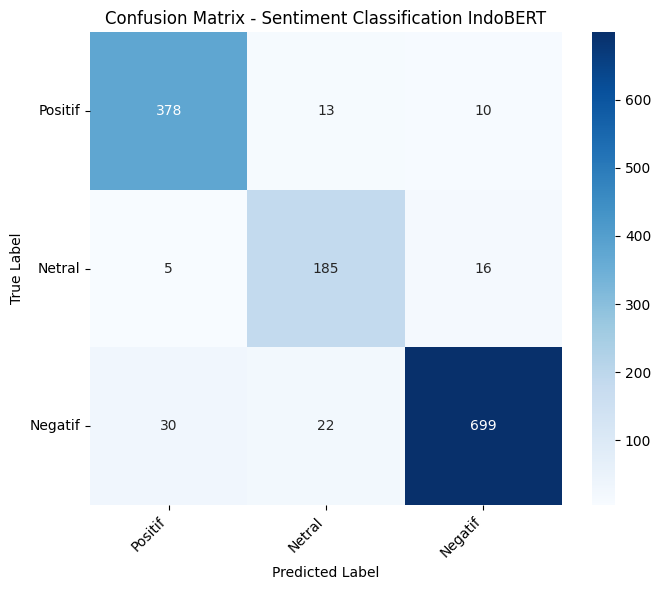

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Hitung confusion matrix
cm = confusion_matrix(all_labels_sentiment, all_preds_sentiment)

# Mapping nama sentimen
sentiment_names = {
   0: 'Positif',
   1: 'Netral',
   2: 'Negatif'
}
sentiment_categories = [sentiment_names[i] for i in sorted(sentiment_names.keys())]

# Ubah ke DataFrame biar ada nama sentimen
cm_df = pd.DataFrame(cm, index=sentiment_categories, columns=sentiment_categories)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Sentiment Classification IndoBERT")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

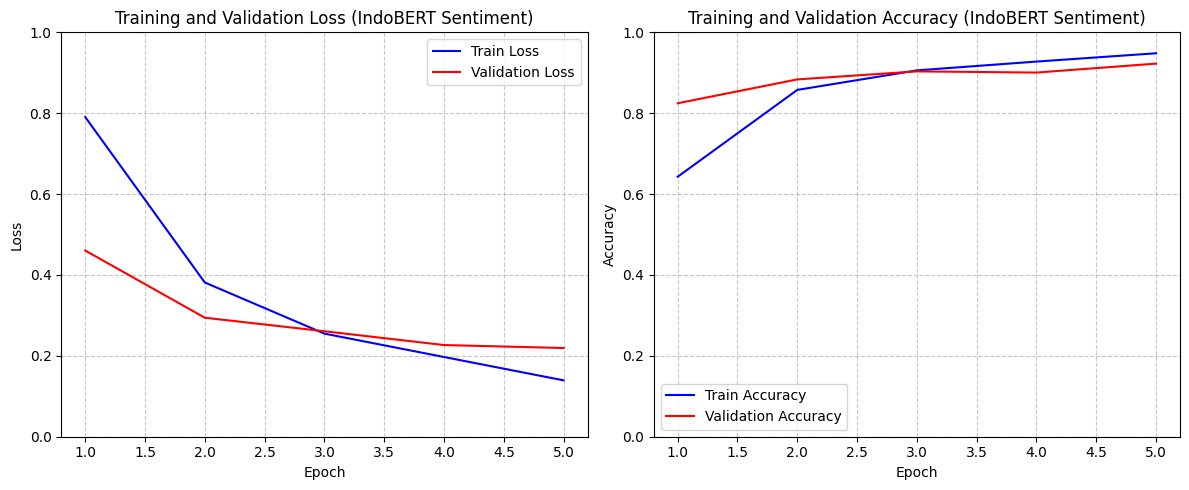

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_sentiment_indobert['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 🔸 Subplot 1: Loss
ax1.plot(epochs, history_sentiment_indobert['train_loss'],
         label='Train Loss', color='blue')
ax1.plot(epochs, history_sentiment_indobert['val_loss'],
         label='Validation Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss (IndoBERT Sentiment)')
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 🔸 Subplot 2: Accuracy
ax2.plot(epochs, history_sentiment_indobert['train_acc'],
         label='Train Accuracy', color='blue')
ax2.plot(epochs, history_sentiment_indobert['val_acc'],
         label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy (IndoBERT Sentiment)')
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, data_loader, device, aspect_categories, dataset_name="Data"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n=== EVALUASI {dataset_name.upper()} ===")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=sentiment_categories,
        digits=4
    ))

    return all_labels, all_preds

In [ ]:
# Train
train_labels, train_preds = evaluate_model(
    model_sentiment_indobert,
    train_loader_sentiment,
    device,
    sentiment_categories,
    dataset_name="Train"
)

# Validation
val_labels, val_preds = evaluate_model(
    model_sentiment_indobert,
    val_loader_sentiment,
    device,
    sentiment_categories,
    dataset_name="Validation"
)


=== EVALUASI TRAIN ===

Classification Report:
              precision    recall  f1-score   support

     Positif     0.9794    0.9936    0.9865      1869
      Netral     0.9307    0.9886    0.9588       964
     Negatif     0.9980    0.9732    0.9854      3502

    accuracy                         0.9815      6335
   macro avg     0.9693    0.9851    0.9769      6335
weighted avg     0.9822    0.9815    0.9817      6335


=== EVALUASI VALIDATION ===

Classification Report:
              precision    recall  f1-score   support

     Positif     0.9089    0.9475    0.9278       400
      Netral     0.8349    0.8792    0.8565       207
     Negatif     0.9571    0.9213    0.9389       750

    accuracy                         0.9226      1357
   macro avg     0.9003    0.9160    0.9077      1357
weighted avg     0.9242    0.9226    0.9230      1357



## **Klasifikasi Berdasarkan Aspek**

In [ ]:
all_aspects = []
all_preds_sentiment = []
all_labels_sentiment = []

In [ ]:
with torch.no_grad():
    for i, batch in enumerate(test_loader_sentiment):

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model_sentiment_indobert(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds_sentiment.extend(preds.cpu().numpy())
        all_labels_sentiment.extend(labels.cpu().numpy())

In [ ]:
import pandas as pd

df_eval_indobert = pd.DataFrame({
    'aspect': aspect_test.reset_index(drop=True),
    'y_true': all_labels_sentiment,
    'y_pred': all_preds_sentiment
})

In [ ]:
from sklearn.metrics import classification_report

for asp in df_eval_indobert['aspect'].unique():

    print(f"\n===== ASPEK: {asp} =====")

    subset = df_eval_indobert[
        df_eval_indobert['aspect'] == asp
    ]

    print("Jumlah data:", len(subset))

    print(classification_report(
        subset['y_true'],
        subset['y_pred']
    ))


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
Jumlah data: 647
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       117
           1       0.85      0.91      0.88       134
           2       0.96      0.92      0.94       396

    accuracy                           0.91       647
   macro avg       0.88      0.90      0.89       647
weighted avg       0.91      0.91      0.91       647


===== ASPEK: Dukungan terhadap Program =====
Jumlah data: 262
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       165
           1       0.76      0.81      0.79        27
           2       0.95      0.90      0.93        70

    accuracy                           0.95       262
   macro avg       0.90      0.90      0.90       262
weighted avg       0.95      0.95      0.95       262


===== ASPEK: Pelaksanaan Program di Sekolah =====
Jumlah data: 449
              precision    recall  

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = sorted(df_eval_indobert['y_true'].unique())

for asp in df_eval_indobert['aspect'].unique():

    print(f"\n===== ASPEK: {asp} =====")

    subset = df_eval_indobert[
        df_eval_indobert['aspect'] == asp
    ]

    cm = confusion_matrix(
        subset['y_true'],
        subset['y_pred'],
        labels=labels
    )

    cm_df_indobert = pd.DataFrame(
        cm,
        index=labels,
        columns=labels
    )

    print(cm_df_indobert)


===== ASPEK: Ketidaksetujuan dan Risiko Program =====
     0    1    2
0  102    9    6
1    2  122   10
2   18   13  365

===== ASPEK: Dukungan terhadap Program =====
     0   1   2
0  163   2   0
1    2  22   3
2    2   5  63

===== ASPEK: Pelaksanaan Program di Sekolah =====
     0   1    2
0  113   2    4
1    1  41    3
2   10   4  271


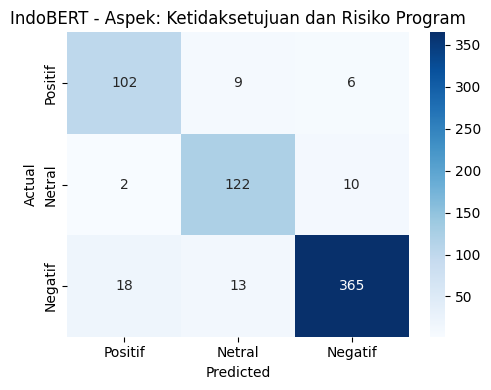

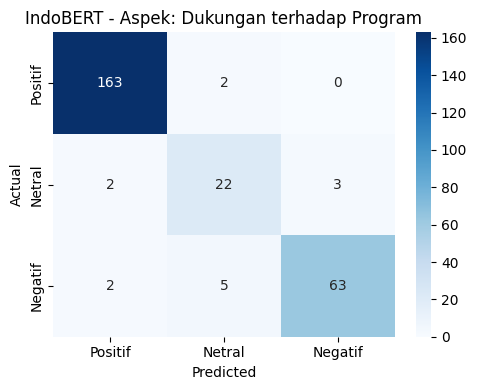

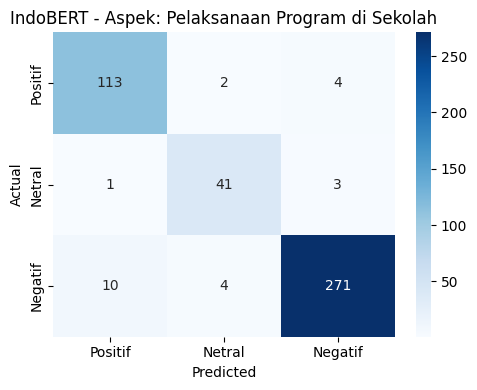

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# mapping label
label_map = {
    0: 'Positif',
    1: 'Netral',
    2: 'Negatif'
}

labels = sorted(df_eval_indobert['y_true'].unique())
label_names = [label_map[l] for l in labels]

for asp in df_eval_indobert['aspect'].unique():

    subset = df_eval_indobert[
        df_eval_indobert['aspect'] == asp
    ]

    cm = confusion_matrix(
        subset['y_true'],
        subset['y_pred'],
        labels=labels
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f'IndoBERT - Aspek: {asp}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

# **Implementasi Model Terbaik ke Aspect-Based Sentiment Classification**

Sumber Komentar untuk Data Baru : [link text](https://vt.tiktok.com/ZSHoyBcuW/)

In [ ]:
# Input Data Baru
new_texts = [
    "tutup mbg dialihkan kependidikan gratis",
    "mbg tuh menurut ku ngga efektif, karena asli di lapangan makanannya banyak yang tidak disukai para siswa. kadang banyak yg kebuang, dan kadang dibawa para guru pulang karena mubazir. tolong lah pak Prabowo buka mata hati karena bukan program BPK yg salah. tp pengolahan dilapangan kurang tepat 😭",
    "padahal dengan adanya mbg banyak membawa dampak positif contohnya bisa menciptakan lapangan pekerjaan",
    "Anggaran nya gk cuma ngurangin pendidikan tp semua nya kenaa.. kn effisiensi.",
    "MBG maju terus"

]
new_texts

['tutup mbg dialihkan kependidikan gratis',
 'mbg tuh menurut ku ngga efektif, karena asli di lapangan makanannya banyak yang tidak disukai para siswa. kadang banyak yg kebuang, dan kadang dibawa para guru pulang karena mubazir. tolong lah pak Prabowo buka mata hati karena bukan program BPK yg salah. tp pengolahan dilapangan kurang tepat 😭',
 'padahal dengan adanya mbg banyak membawa dampak positif contohnya bisa menciptakan lapangan pekerjaan',
 'Anggaran nya gk cuma ngurangin pendidikan tp semua nya kenaa.. kn effisiensi.',
 'MBG maju terus']

In [ ]:
data_baru = {
    "text": new_texts,
    "aspect": [0, 0, 2, 0, 2],
    "sentiment": [2, 2, 0, 2, 0]
}

df_new = pd.DataFrame(data_baru)

In [ ]:
# =========================
# DATASET DATA BARU
# =========================
new_dataset = BERTDataset(
    texts=df_new['text'],
    labels=df_new['sentiment'],
    tokenizer=tokenizer,
    max_len=128
)

new_loader = DataLoader(
    new_dataset,
    batch_size=1,
    shuffle=False
)

In [ ]:
# =========================
# PREDIKSI DATA BARU
# =========================
model_sentiment_indobert.eval()

predictions = []

with torch.no_grad():

    for batch in new_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        logits = model_sentiment_indobert(
            input_ids,
            attention_mask
        )

        preds = torch.argmax(logits, dim=1)

        predictions.extend(
            preds.cpu().numpy()
        )

In [ ]:
df_result = df_new.copy()

df_result['pred_sentiment'] = predictions

In [ ]:
label_map_sentiment = {
    0: "Positif",
    1: "Netral",
    2: "Negatif"
}

label_map_aspect = {
    0: "Ketidaksetujuan dan Risiko Program",
    1: "Pelaksanaan Program di Sekolah",
    2: "Dampak Positif Program"
}

In [ ]:
df_result['aspect_name'] = df_result['aspect'].map(label_map_aspect)

df_result['sentiment'] = (
    df_result['sentiment']
    .map(label_map_sentiment)
)

df_result['pred_sentiment'] = (
    df_result['pred_sentiment']
    .map(label_map_sentiment)
)

In [ ]:
df_result[[
    'text',
    'aspect_name',
    'sentiment',
    'pred_sentiment'
]]

,text,aspect_name,sentiment,pred_sentiment
0,tutup mbg dialihkan kependidikan gratis,Ketidaksetujuan dan Risiko Program,Negatif,Netral
1,"mbg tuh menurut ku ngga efektif, karena asli di lapangan makanannya banyak yang tidak disukai para siswa. kadang banyak yg kebuang, dan kadang dibawa para guru pulang karena mubazir. tolong lah pak Prabowo buka mata hati karena bukan program BPK yg salah. tp pengolahan dilapangan kurang tepat 😭",Ketidaksetujuan dan Risiko Program,Negatif,Negatif
2,padahal dengan adanya mbg banyak membawa dampak positif contohnya bisa menciptakan lapangan pekerjaan,Dampak Positif Program,Positif,Positif
3,Anggaran nya gk cuma ngurangin pendidikan tp semua nya kenaa.. kn effisiensi.,Ketidaksetujuan dan Risiko Program,Negatif,Negatif
4,MBG maju terus,Dampak Positif Program,Positif,Positif
